In [ ]:
import os
import torch
import networkx as nx
import random
import matplotlib.pyplot as plt
try:
    import torch_geometric
except ImportError:
    get_ipython().system('pip install -q torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{torch.__version__}.html')
    print("Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 33.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 45.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.7 MB/s eta 0:00:00
Dependencies installed.


In [ ]:
import os
import json
import requests
import sqlite3
from pathlib import Path
from tqdm import tqdm
from urllib.parse import urlparse

NVD_BASE = "https://services.nvd.nist.gov/rest/json"
NVD_FEED_RECENT_URL = "https://nvd.nist.gov/feeds/json/cve/2.0/nvdcve-2.0-recent.json.gz"

def download_and_extract_feed(url, download_to="data/nvd_recent.json"):
    import gzip
    os.makedirs(os.path.dirname(download_to), exist_ok=True)
    r = requests.get(url, stream=True)
    r.raise_for_status()
    tmp = download_to + ".gz"
    with open(tmp, "wb") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk:
                f.write(chunk)
    with gzip.open(tmp, "rb") as gz, open(download_to, "wb") as out:
        out.write(gz.read())
    os.remove(tmp)
    return download_to

def create_db(sqlite_path="data/cve.db"):
    Path(os.path.dirname(sqlite_path)).mkdir(parents=True, exist_ok=True)
    conn = sqlite3.connect(sqlite_path)
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS cve (
        cve_id TEXT PRIMARY KEY,
        summary TEXT,
        publishedDate TEXT,
        lastModifiedDate TEXT,
        cvss_v3 FLOAT,
        cpes TEXT,
        "references" TEXT,
        exploit_available INTEGER
    )
    """)
    cur.execute("CREATE INDEX IF NOT EXISTS idx_cvss ON cve(cvss_v3)")
    conn.commit()
    return conn

def heuristic_exploit_available(references):
    exploit_domains = ("exploit-db.org", "metasploit.com", "rapid7.com", "github.com", "githubusercontent.com")
    for r in references:
        url = r.get("url", "")
        try:
            host = urlparse(url).netloc.lower()
            for d in exploit_domains:
                if d in host:
                    return 1
        except:
            pass
        desc = (r.get("description") or "").lower()
        if "exploit" in desc or "proof of concept" in desc or "poc" in desc:
          return 1

    return 0

def normalize_and_store(nvd_json_path, sqlite_path="data/cve.db"):
    conn = create_db(sqlite_path)
    cur = conn.cursor()

    with open(nvd_json_path, "r", encoding="utf8") as f:
        data = json.load(f)

    cve_items = data.get("vulnerabilities") or data.get("CVE_Items") or []
    if isinstance(cve_items, dict):
        cve_items = cve_items.get("vulnerabilities", [])

    print("Found", len(cve_items), "items - parsing...")

    for item in tqdm(cve_items):
        entry = item.get("cve") if "cve" in item else (item if "cve" in item else item)
        cve_id = None
        summary = ""
        published = None
        modified = None
        cvss_v3 = None
        cpes = []
        references = []

        try:
            cve_id = entry.get("id") or (entry.get("CVE_data_meta") or {}).get("ID")
        except Exception:
            cve_id = None

        if not cve_id:
            cve_id = item.get("cve", {}).get("CVE_data_meta", {}).get("ID") or item.get("cve", {}).get("id")

        for path in [
            lambda e: e.get("descriptions", [{}])[0].get("value") if isinstance(e.get("descriptions"), list) else None,
            lambda e: e.get("summary"),
            lambda e: e.get("cve", {}).get("description", {}).get("description_data", [{}])[0].get("value"),
            lambda e: e.get("cve", {}).get("descriptions", [{}])[0].get("value")
        ]:
            try:
                val = path(item)
                if val:
                    summary = val
                    break
            except Exception:
                pass

        published = item.get("publishedDate") or item.get("cve", {}).get("publishedDate") or item.get("published")
        modified = item.get("lastModifiedDate") or item.get("cve", {}).get("lastModifiedDate") or item.get("lastModified")

        try:
            metrics = item.get("cve", {}).get("metrics", {})
            if "cvssMetricV31" in metrics:
                cvss_v3 = metrics["cvssMetricV31"][0]["cvssData"]["baseScore"]
            elif "cvssMetricV30" in metrics:
                cvss_v3 = metrics["cvssMetricV30"][0]["cvssData"]["baseScore"]
            else:
                cvss_v3 = None
        except Exception:
            cvss_v3 = None

        try:
            nodes = item.get("cve", {}).get("configurations", {}).get("nodes", []) or []
            if not nodes:
                nodes = item.get("configurations", {}).get("nodes", [])
            for node in nodes:
                for match in node.get("cpeMatch", []) + node.get("cpe_matches", []):
                    uri = match.get("cpe23Uri") or match.get("cpe") or match.get("cpeUri")
                    if uri:
                        cpes.append(uri)
        except Exception:
            pass

        try:
            refs = []
            for r in item.get("cve", {}).get("references", {}).get("reference_data", []) or item.get("cve", {}).get("references", []) or []:
                refs.append({"url": r.get("url"), "description": r.get("description")})
            if not refs:
                for r in item.get("references", []):
                    refs.append({"url": r.get("url"), "description": r.get("description", "")})
            references = refs
        except Exception:
            references = []

        if not cve_id:
            possible = item.get("id") or item.get("name")
            if possible:
                cve_id = possible

        if not cve_id:
            continue

        exploit_flag = heuristic_exploit_available(references)

        cur.execute("""
            INSERT OR REPLACE INTO cve (cve_id, summary, publishedDate, lastModifiedDate, cvss_v3, cpes, "references", exploit_available)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (cve_id, summary, published, modified, cvss_v3, json.dumps(cpes), json.dumps(references), exploit_flag))
    conn.commit()
    conn.close()
    print("Done. DB stored at", sqlite_path)

if __name__ == "__main__":
    path = download_and_extract_feed(NVD_FEED_RECENT_URL, download_to="data/nvd_recent.json")
    normalize_and_store(path, sqlite_path="data/cve.db")

Found 1373 items - parsing...


100%|██████████| 1373/1373 [00:00<00:00, 32040.92it/s]

Done. DB stored at data/cve.db


In [ ]:
import sqlite3
import json
import re

SERVICE_ALIASES = {
    "SMB":      ["smb", "samba"],
    "RDP":      ["rdp", "remote desktop"],
    "Netlogon": ["netlogon"],
    "OpenSSL":  ["openssl", "tls", "ssl"],
    "SSH":      ["ssh", "secure shell"],
    "HTTP":     ["http", "apache", "nginx", "iis"],
    "Java":     ["java", "jvm", "tomcat", "jre"]
}

# ============================================================
# ADDED: SERVICE_PORTS — maps each service to its real-world
# port numbers and protocol. Used by Firewall and vuln tagging.
# Each service can have multiple ports (e.g. HTTP runs on 80 and 8080).
# ============================================================
SERVICE_PORTS = {
    "SSH":      [{"port": 22,   "protocol": "TCP"}],
    "HTTP":     [{"port": 80,   "protocol": "TCP"},
                 {"port": 8080, "protocol": "TCP"}],
    "OpenSSL":  [{"port": 443,  "protocol": "TCP"},
                 {"port": 8443, "protocol": "TCP"}],
    "SMB":      [{"port": 445,  "protocol": "TCP"},
                 {"port": 139,  "protocol": "TCP"}],
    "RDP":      [{"port": 3389, "protocol": "TCP"}],
    "Netlogon": [{"port": 135,  "protocol": "TCP"},
                 {"port": 445,  "protocol": "TCP"}],
    "Java":     [{"port": 8080, "protocol": "TCP"},
                 {"port": 8009, "protocol": "TCP"}],
    "SMTP":     [{"port": 25,   "protocol": "TCP"},
                 {"port": 587,  "protocol": "TCP"}],
    "LDAP":     [{"port": 389,  "protocol": "TCP"},
                 {"port": 636,  "protocol": "TCP"}],
    "MySQL":    [{"port": 3306, "protocol": "TCP"}],
    "MSSQL":    [{"port": 1433, "protocol": "TCP"}],
}

# ============================================================
# ADDED: HOST_ROLES — defines fixed server roles per subnet.
# Each role has a deterministic OS and service list.
# This replaces the previous random OS + random service assignment,
# making the network model realistic and research-defensible.
# ============================================================
HOST_ROLES = {
    "DMZ": [
        {
            "role":     "Web Server",
            "os":       "Linux",
            "services": ["HTTP", "OpenSSL", "SSH"]
        },
        {
            "role":     "Mail Server",
            "os":       "Linux",
            "services": ["SMTP", "OpenSSL", "SSH"]
        },
    ],
    "User_LAN": [
        {
            "role":     "App Server",
            "os":       "Linux",
            "services": ["HTTP", "Java", "SSH"]
        },
        {
            "role":     "Windows Workstation",
            "os":       "Windows",
            "services": ["SMB", "RDP", "Netlogon"]
        },
    ],
    "Data_Center": [
        {
            "role":     "Database Server",
            "os":       "Linux",
            "services": ["MySQL", "SSH"]
        },
        {
            "role":     "Auth Server",
            "os":       "Windows",
            "services": ["LDAP", "Netlogon", "SMB"]
        },
        {
            "role":     "Backup Server",
            "os":       "Linux",
            "services": ["SSH", "MSSQL"]
        },
    ],
}

# ============================================================
# ADDED: ROLE_CONNECTIONS — defines which roles can talk to
# which other roles. This replaces random-probability edges
# with explicit, realistic role-based connectivity rules.
# e.g. Web Server → App Server (frontend calls backend)
#      App Server → Database Server (backend queries DB)
# ============================================================
ROLE_CONNECTIONS = [
    ("Web Server",          "App Server"),
    ("Mail Server",         "App Server"),
    ("App Server",          "Database Server"),
    ("App Server",          "Auth Server"),
    ("Windows Workstation", "Auth Server"),
    ("Windows Workstation", "App Server"),
    ("Auth Server",         "Database Server"),
    ("Auth Server",         "Backup Server"),
    ("Database Server",     "Backup Server"),
]

def find_cves_for_services(services, sqlite_path="data/cve.db", max_results=50):
    conn = sqlite3.connect(sqlite_path)
    cur = conn.cursor()
    results = []
    # UNCHANGED: service-name-based CVE lookup logic kept exactly as before
    for svc in services:
        aliases = SERVICE_ALIASES.get(svc, [svc.lower()])
        query = f"""
        SELECT cve_id, summary, cvss_v3, cpes, "references", exploit_available
        FROM cve
        WHERE lower(summary) LIKE '%' || ? || '%'
           OR lower(cpes) LIKE '%' || ? || '%'
        LIMIT ?
        """
        cur.execute(query, (aliases[0], aliases[0], max_results))
        for row in cur.fetchall():
            cve_id, summary, cvss_v3, cpes_json, refs_json, exploit_flag = row
            results.append({
                "cve":     cve_id,
                "summary": summary,
                "cvss":    cvss_v3,
                "cpes":    json.loads(cpes_json or "[]"),
                "exploit": bool(exploit_flag)
            })
    conn.close()
    seen = set()
    uniq = []
    for r in results:
        if r["cve"] not in seen:
            uniq.append(r)
            seen.add(r["cve"])
    return uniq[:max_results]

In [ ]:
import networkx as nx
import random
import math
import numpy as np


# UNCHANGED: CVSS → probability sigmoid mapping
def cvss_to_probability(cvss, exploit_available):
    x = (cvss - 6) / 2.5
    base = 1 / (1 + math.exp(-x))
    if exploit_available:
        base *= 1.4
    else:
        base *= 0.6
    return max(0.01, min(base, 0.98))


# ============================================================
# ADDED: Firewall class — port-aware, protocol-aware firewall.
# Rules are evaluated top-down; first match wins.
# Default policy is DENY (if no rule matches, traffic is blocked).
# This models real enterprise firewall behavior (e.g. iptables,
# Cisco ACL, Palo Alto) and is citable in the threat model section.
# ============================================================
class Firewall:
    def __init__(self, name, src_subnet, dst_subnet):
        self.name       = name
        self.src_subnet = src_subnet
        self.dst_subnet = dst_subnet
        self.rules      = []   # evaluated top-down; first match wins

    def add_rule(self, action, service=None, port=None, protocol=None):
        """
        action:   "ALLOW" or "DENY"
        service:  service name string or None (None = wildcard, matches any)
        port:     integer port number or None (None = wildcard)
        protocol: "TCP" / "UDP" or None (None = wildcard)
        """
        self.rules.append({
            "action":   action,
            "service":  service,
            "port":     port,
            "protocol": protocol,
        })

    def evaluate(self, service, port, protocol="TCP"):
        """
        Returns True if traffic is ALLOWED, False if DENIED.
        Wildcard fields (None) match any value.
        Default-deny if no rule matches — this is the safe default.
        """
        for rule in self.rules:
            svc_match  = (rule["service"]  is None or rule["service"]  == service)
            port_match = (rule["port"]     is None or rule["port"]     == port)
            proto_match= (rule["protocol"] is None or rule["protocol"] == protocol)
            if svc_match and port_match and proto_match:
                return rule["action"] == "ALLOW"
        return False   # default-deny


# ============================================================
# ADDED: _setup_firewalls() — instantiates three firewalls,
# one per subnet boundary, with explicit documented rules.
# These rules are the "threat model" you cite in the paper.
# FW1: Internet→DMZ   — only allow HTTP/HTTPS inbound
# FW2: DMZ→User_LAN   — allow app-tier traffic, block RDP/SMB
# FW3: LAN→DataCenter — strict: only DB and LDAP ports allowed
# ============================================================
def _setup_firewalls():
    firewalls = {}

    # --- FW1: Internet → DMZ ---
    # Allows only web traffic inbound. Blocks all admin protocols.
    fw1 = Firewall("FW1_Internet_DMZ", "Internet", "DMZ")
    fw1.add_rule("ALLOW", service="HTTP",    port=80,   protocol="TCP")
    fw1.add_rule("ALLOW", service="OpenSSL", port=443,  protocol="TCP")
    fw1.add_rule("ALLOW", service="SMTP",    port=25,   protocol="TCP")
    fw1.add_rule("DENY",  service="SSH",     port=22,   protocol="TCP")   # no SSH from internet
    fw1.add_rule("DENY",  service="RDP",     port=3389, protocol="TCP")   # no RDP from internet
    fw1.add_rule("DENY",  service="SMB",     port=445,  protocol="TCP")   # no SMB from internet
    fw1.add_rule("DENY",  service=None,      port=None, protocol=None)    # deny everything else
    firewalls[("Internet", "DMZ")] = fw1

    # --- FW2: DMZ → User_LAN ---
    # DMZ servers may call app servers on HTTP/Java ports only.
    fw2 = Firewall("FW2_DMZ_LAN", "DMZ", "User_LAN")
    fw2.add_rule("ALLOW", service="HTTP",    port=80,   protocol="TCP")
    fw2.add_rule("ALLOW", service="Java",    port=8080, protocol="TCP")
    fw2.add_rule("ALLOW", service="SSH",     port=22,   protocol="TCP")
    fw2.add_rule("DENY",  service="RDP",     port=3389, protocol="TCP")
    fw2.add_rule("DENY",  service="SMB",     port=445,  protocol="TCP")
    fw2.add_rule("DENY",  service="SMB",     port=139,  protocol="TCP")
    fw2.add_rule("DENY",  service=None,      port=None, protocol=None)
    firewalls[("DMZ", "User_LAN")] = fw2

    # --- FW3: User_LAN → Data_Center ---
    # Only database and auth queries allowed; everything else blocked.
    fw3 = Firewall("FW3_LAN_DC", "User_LAN", "Data_Center")
    fw3.add_rule("ALLOW", service="MySQL",   port=3306, protocol="TCP")
    fw3.add_rule("ALLOW", service="MSSQL",   port=1433, protocol="TCP")
    fw3.add_rule("ALLOW", service="LDAP",    port=389,  protocol="TCP")
    fw3.add_rule("DENY",  service="SSH",     port=22,   protocol="TCP")
    fw3.add_rule("DENY",  service="RDP",     port=3389, protocol="TCP")
    fw3.add_rule("DENY",  service=None,      port=None, protocol=None)
    firewalls[("User_LAN", "Data_Center")] = fw3

    return firewalls


class NetworkGenerator:
    def __init__(self, num_hosts=20):
        self.num_hosts   = num_hosts
        self.cve_sqlite  = cve_sqlite
        self.topology    = nx.DiGraph()
        self.attack_graph= nx.DiGraph()
        self.subnets     = ["DMZ", "User_LAN", "Data_Center"]
        # ADDED: load firewall rules at construction time
        self.firewalls   = _setup_firewalls()

    # ============================================================
    # CHANGED: generate_random_host() →  generate_role_host()
    # Instead of random OS + random services, each host is assigned
    # a deterministic role from HOST_ROLES based on its subnet.
    # Role determines OS and services — making the network realistic.
    # The vuln-fetching logic is UNCHANGED.
    # ============================================================
    def generate_role_host(self, host_id, subnet):
        # Pick a role definition from the subnet's role list (round-robin)
        role_list  = HOST_ROLES[subnet]
        role_def   = role_list[host_id % len(role_list)]
        role       = role_def["role"]
        os_type    = role_def["os"]
        svc_names  = role_def["services"]

        # ADDED: attach port + protocol info to each service on this host
        services = []
        for svc in svc_names:
            for port_entry in SERVICE_PORTS.get(svc, [{"port": None, "protocol": "TCP"}]):
                services.append({
                    "name":     svc,
                    "port":     port_entry["port"],
                    "protocol": port_entry["protocol"],
                })

        # UNCHANGED: CVE lookup logic — still queries NVD SQLite DB
        vulns = []
        if random.random() > 0.3:
            real_cves = find_cves_for_services(svc_names, sqlite_path=self.cve_sqlite, max_results=20)
            if real_cves:
                picks = random.sample(real_cves, k=min(len(real_cves), random.randint(1, 3)))
                for p in picks:
                    # ADDED: pick a specific service+port for each vuln
                    # (previously service was random choice from name list only)
                    matched_svc = random.choice(services)
                    vulns.append({
                        "cve":      p["cve"],
                        "cvss":     p["cvss"],
                        "service":  matched_svc["name"],
                        "port":     matched_svc["port"],      # ADDED
                        "protocol": matched_svc["protocol"],  # ADDED
                        "exploit":  p["exploit"]
                    })

        return {
            "id":          host_id,
            "ip":          f"192.168.{random.randint(1,10)}.{host_id}",
            "subnet":      subnet,
            "role":        role,          # ADDED
            "os":          os_type,
            "services":    services,      # now list of dicts with name/port/protocol
            "vulns":       vulns,
            "compromised": False,
        }

    # ============================================================
    # CHANGED: build_topology()
    # Connectivity is now role-based (ROLE_CONNECTIONS) instead of
    # random probability edges. Lateral movement edges within the
    # same subnet are also added — this was missing before.
    # ============================================================
    def build_topology(self):
        attacker = {"id": "Attacker", "subnet": "Internet", "role": "Attacker", "vulns": []}
        self.topology.add_node("Attacker", **attacker)

        for i in range(self.num_hosts):
            if i < self.num_hosts * 0.2:
                subnet = "DMZ"
            elif i < self.num_hosts * 0.7:
                subnet = "User_LAN"
            else:
                subnet = "Data_Center"

            # CHANGED: use role-based host generation
            host_data = self.generate_role_host(i, subnet)
            self.topology.add_node(i, **host_data)

        # Attacker → all DMZ nodes (UNCHANGED logic)
        dmz_nodes = [n for n, d in self.topology.nodes(data=True) if d.get('subnet') == "DMZ"]
        for node in dmz_nodes:
            self.topology.add_edge("Attacker", node, type="physical")

        # CHANGED: role-based inter-subnet edges instead of random probability
        all_nodes = [(n, d) for n, d in self.topology.nodes(data=True) if n != "Attacker"]
        for (src_role, dst_role) in ROLE_CONNECTIONS:
            src_nodes = [n for n, d in all_nodes if d.get("role") == src_role]
            dst_nodes = [n for n, d in all_nodes if d.get("role") == dst_role]
            for s in src_nodes:
                for d in dst_nodes:
                    self.topology.add_edge(s, d, type="physical")

        # ADDED: lateral movement edges within User_LAN (Windows Workstations
        # can reach each other via SMB/Netlogon — common in real AD environments)
        lan_workstations = [n for n, d in self.topology.nodes(data=True)
                            if d.get("role") == "Windows Workstation"]
        for i, src in enumerate(lan_workstations):
            for dst in lan_workstations[i+1:]:
                # bidirectional lateral movement
                self.topology.add_edge(src, dst, type="lateral")
                self.topology.add_edge(dst, src, type="lateral")

        print(f"Topology Built: {self.topology.number_of_nodes()} nodes, {self.topology.number_of_edges()} links.")

    # ============================================================
    # CHANGED: compute_attack_graph()
    # Now enforces firewall rules per subnet boundary before adding
    # exploit edges. Service matching now checks by name (from the
    # services list of dicts). Port is passed to firewall.evaluate().
    # Blocked edges are printed for transparency/logging.
    # ============================================================
    def compute_attack_graph(self):
        self.attack_graph = nx.DiGraph()

        for n, data in self.topology.nodes(data=True):
            self.attack_graph.add_node(n, **data)

        blocked_count = 0
        allowed_count = 0

        for u, v in self.topology.edges():
            src_subnet = self.topology.nodes[u].get('subnet', 'Unknown')
            tgt_subnet = self.topology.nodes[v].get('subnet', 'Unknown')

            # CHANGED: services is now a list of dicts; extract names for matching
            target_service_names = [s["name"] for s in self.topology.nodes[v].get('services', [])]
            target_vulns         = self.topology.nodes[v].get('vulns', [])

            # ADDED: look up applicable firewall for this subnet boundary
            fw = self.firewalls.get((src_subnet, tgt_subnet))

            for vuln in target_vulns:
                # UNCHANGED: service-on-host check
                if vuln['service'] not in target_service_names:
                    continue
                if vuln['cvss'] is None:
                    continue

                # ADDED: firewall enforcement — check port + protocol
                vuln_port     = vuln.get('port')
                vuln_protocol = vuln.get('protocol', 'TCP')
                if fw and not fw.evaluate(vuln['service'], vuln_port, vuln_protocol):
                    blocked_count += 1
                    print(f"  [FW BLOCKED] {fw.name}: {u}→{v} | "
                          f"{vuln['service']}:{vuln_port} | {vuln['cve']}")
                    continue

                prob = cvss_to_probability(vuln['cvss'], vuln['exploit'])
                allowed_count += 1

                self.attack_graph.add_edge(
                    u, v,
                    vuln_id=vuln['cve'],
                    service=vuln['service'],
                    port=vuln_port,           # ADDED
                    protocol=vuln_protocol,   # ADDED
                    weight=prob,
                    cvss=vuln['cvss'],
                    type="exploit",
                    firewall=fw.name if fw else "none"   # ADDED: audit trail
                )

        print(f"\nAttack Graph Generated: {allowed_count} exploit paths allowed, "
              f"{blocked_count} blocked by firewalls.")
        return self.attack_graph


# ---- Run ----
cve_sqlite = "data/cve.db"
gen = NetworkGenerator(num_hosts=30)
gen.build_topology()
AG = gen.compute_attack_graph()

combined_graph = nx.DiGraph()
for n, d in gen.topology.nodes(data=True):
    combined_graph.add_node(n, **d)
for u, v, d in gen.topology.edges(data=True):
    if not combined_graph.has_edge(u, v):
        combined_graph.add_edge(u, v, **d)
for u, v, d in AG.edges(data=True):
    combined_graph.add_edge(u, v, **d)

Topology Built: 31 nodes, 248 links.
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→1 | OpenSSL:8443 | CVE-2026-41898
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→1 | SMTP:587 | CVE-2026-41681
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→4 | HTTP:8080 | CVE-2026-42043
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→4 | OpenSSL:8443 | CVE-2026-42041
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→5 | SSH:22 | CVE-2026-7598
  [FW BLOCKED] FW1_Internet_DMZ: Attacker→5 | SSH:22 | CVE-2026-41898
  [FW BLOCKED] FW2_DMZ_LAN: 0→6 | Java:8009 | CVE-2026-41492
  [FW BLOCKED] FW2_DMZ_LAN: 0→6 | HTTP:8080 | CVE-2026-42034
  [FW BLOCKED] FW2_DMZ_LAN: 0→8 | Java:8009 | CVE-2026-41321
  [FW BLOCKED] FW2_DMZ_LAN: 0→10 | Java:8009 | CVE-2026-41321
  [FW BLOCKED] FW2_DMZ_LAN: 0→18 | Java:8009 | CVE-2026-31586
  [FW BLOCKED] FW2_DMZ_LAN: 0→18 | Java:8009 | CVE-2026-42044
  [FW BLOCKED] FW2_DMZ_LAN: 0→20 | Java:8009 | CVE-2026-41323
  [FW BLOCKED] FW2_DMZ_LAN: 0→20 | HTTP:8080 | CVE-2026-42041
  [FW BLOCKED] FW2_DMZ_LAN: 1→6 | 

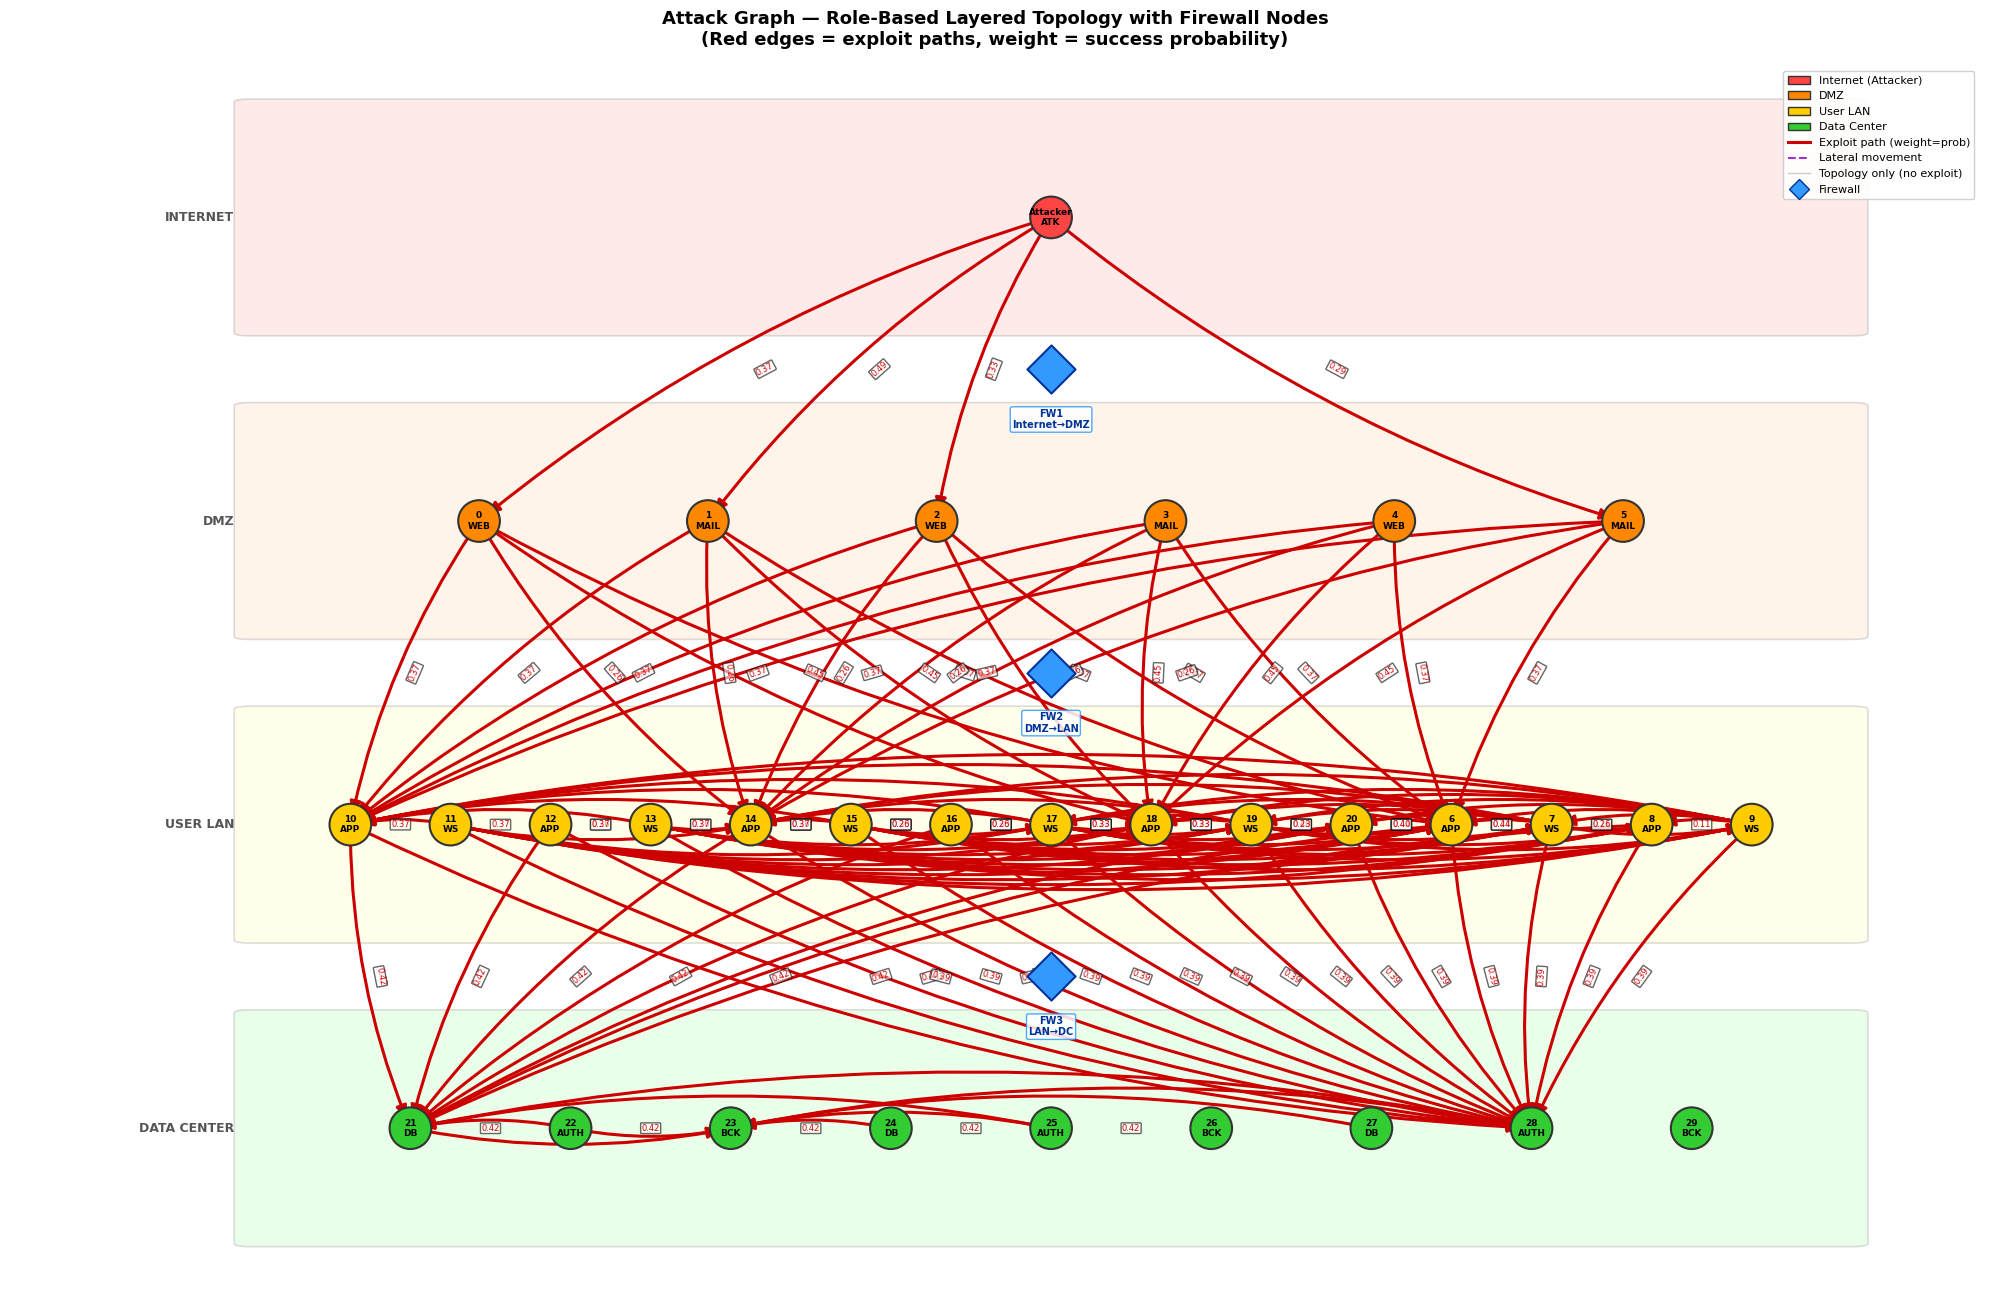

In [ ]:
def visualize_ag(G, firewalls=None):
    from matplotlib.patches import Patch, FancyBboxPatch
    from matplotlib.lines import Line2D
    import matplotlib.patches as mpatches

    fig, ax = plt.subplots(figsize=(20, 13))

    # ----------------------------------------------------------
    # STEP 1: Assign Y positions by subnet band.
    # Each subnet gets a fixed Y level; nodes spread on X axis.
    # Attacker sits at Y=3.0 (top). DC sits at Y=0.0 (bottom).
    # ----------------------------------------------------------
    SUBNET_Y = {
        "Internet":    3.0,
        "DMZ":         2.0,
        "User_LAN":    1.0,
        "Data_Center": 0.0,
    }

    # Group nodes by subnet
    subnet_buckets = {"Internet": [], "DMZ": [], "User_LAN": [], "Data_Center": []}
    for node in G.nodes():
        sn = G.nodes[node].get('subnet', 'Internet')
        subnet_buckets.setdefault(sn, []).append(node)

    # Spread nodes evenly across X=0..1 within each subnet band
    pos = {}
    for sn, nodes in subnet_buckets.items():
        y = SUBNET_Y.get(sn, 0.5)
        n = len(nodes)
        for i, node in enumerate(sorted(nodes, key=lambda x: str(x))):
            x = (i + 1) / (n + 1)   # evenly spaced, away from edges
            pos[node] = (x, y)

    # ----------------------------------------------------------
    # STEP 2: Draw subnet background bands so the zone structure
    # is immediately visible — no need to read node colors alone.
    # ----------------------------------------------------------
    band_colors = {
        "Internet":    "#ffcccc",   # light red
        "DMZ":         "#ffe5cc",   # light orange
        "User_LAN":    "#ffffcc",   # light yellow
        "Data_Center": "#ccffcc",   # light green
    }
    band_labels_text = {
        "Internet":    "INTERNET",
        "DMZ":         "DMZ",
        "User_LAN":    "USER LAN",
        "Data_Center": "DATA CENTER",
    }
    for sn, y_center in SUBNET_Y.items():
        rect = mpatches.FancyBboxPatch(
            (0, y_center - 0.38), 1.0, 0.76,
            boxstyle="round,pad=0.01",
            linewidth=1.2, edgecolor='#aaaaaa',
            facecolor=band_colors[sn], alpha=0.4,
            transform=ax.transData, zorder=0
        )
        ax.add_patch(rect)
        ax.text(-0.01, y_center, band_labels_text[sn],
                fontsize=9, fontweight='bold', color='#555555',
                va='center', ha='right', transform=ax.transData)

    # ----------------------------------------------------------
    # STEP 3: Draw FIREWALL nodes between subnet bands.
    # Positioned at midpoints between adjacent subnet Y levels.
    # Visual only — not in the graph data structure.
    # ----------------------------------------------------------
    fw_positions = {
        "FW1\nInternet→DMZ":  (0.5, 2.5),    # between Internet and DMZ
        "FW2\nDMZ→LAN":       (0.5, 1.5),    # between DMZ and LAN
        "FW3\nLAN→DC":        (0.5, 0.5),    # between LAN and DC
    }
    for fw_label, (fx, fy) in fw_positions.items():
        # Draw as a blue diamond shape using scatter with marker='D'
        ax.scatter(fx, fy, s=600, c='#3399ff', marker='D',
                   zorder=5, linewidths=1.5, edgecolors='#003399')
        ax.text(fx, fy - 0.13, fw_label, fontsize=7, color='#003399',
                ha='center', va='top', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#3399ff', alpha=0.85))

    # ----------------------------------------------------------
    # STEP 4: Draw edges.
    # Exploit edges (have 'weight') → red, thicker, with prob label.
    # Lateral movement edges → purple, dashed.
    # No-weight edges (physical topology only) → light grey, thin.
    # ----------------------------------------------------------

    # Separate edges by type for different styling
    exploit_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get('weight') is not None]
    lateral_edges  = [(u, v) for u, v, d in G.edges(data=True)
                      if d.get('type') == 'lateral' and d.get('weight') is None]
    topology_edges = [(u, v) for u, v, d in G.edges(data=True)
                      if d.get('weight') is None and d.get('type') != 'lateral']

    # Draw topology-only edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, edgelist=topology_edges,
                           edge_color='#cccccc', width=1.0,
                           arrowsize=10, ax=ax,
                           connectionstyle='arc3,rad=0.05')

    # Draw lateral movement edges (purple dashed)
    nx.draw_networkx_edges(G, pos, edgelist=lateral_edges,
                           edge_color='#9933cc', width=1.2, style='dashed',
                           arrowsize=10, ax=ax,
                           connectionstyle='arc3,rad=0.15')

    # Draw exploit edges (red, thick — these are the attack paths)
    nx.draw_networkx_edges(G, pos, edgelist=exploit_edges,
                           edge_color='#cc0000', width=2.2,
                           arrowsize=16, ax=ax,
                           connectionstyle='arc3,rad=0.1')

    # Edge probability labels — only on exploit edges, small font
    exploit_edge_labels = {
        (u, v): f"{d['weight']:.2f}"
        for u, v, d in G.edges(data=True) if d.get('weight') is not None
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=exploit_edge_labels,
                                 font_color='#cc0000', font_size=6,
                                 bbox=dict(boxstyle='round,pad=0.1',
                                           facecolor='white', alpha=0.6),
                                 ax=ax)

    # ----------------------------------------------------------
    # STEP 5: Draw nodes with role-abbreviated labels.
    # Abbreviate role names so they fit inside nodes cleanly.
    # ----------------------------------------------------------
    ROLE_ABBREV = {
        "Attacker":            "ATK",
        "Web Server":          "WEB",
        "Mail Server":         "MAIL",
        "App Server":          "APP",
        "Windows Workstation": "WS",
        "Database Server":     "DB",
        "Auth Server":         "AUTH",
        "Backup Server":       "BCK",
    }

    node_colors = []
    for node in G.nodes():
        sn = G.nodes[node].get('subnet', 'Unknown')
        if sn == 'Internet':      node_colors.append('#ff4444')
        elif sn == 'DMZ':         node_colors.append('#ff8800')
        elif sn == 'User_LAN':    node_colors.append('#ffcc00')
        elif sn == 'Data_Center': node_colors.append('#33cc33')
        else:                     node_colors.append('#aaaaaa')

    node_labels = {}
    for node in G.nodes():
        role = G.nodes[node].get('role', str(node))
        abbrev = ROLE_ABBREV.get(role, str(node))
        node_labels[node] = f"{node}\n{abbrev}"

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=900, ax=ax,
                           linewidths=1.5, edgecolors='#333333')
    nx.draw_networkx_labels(G, pos, labels=node_labels,
                            font_size=6.5, font_weight='bold', ax=ax)

    # ----------------------------------------------------------
    # STEP 6: Legend
    # ----------------------------------------------------------
    legend_elements = [
        Patch(facecolor='#ff4444', edgecolor='#333333', label='Internet (Attacker)'),
        Patch(facecolor='#ff8800', edgecolor='#333333', label='DMZ'),
        Patch(facecolor='#ffcc00', edgecolor='#333333', label='User LAN'),
        Patch(facecolor='#33cc33', edgecolor='#333333', label='Data Center'),
        Line2D([0],[0], color='#cc0000', linewidth=2.2, label='Exploit path (weight=prob)'),
        Line2D([0],[0], color='#9933cc', linewidth=1.5,
               linestyle='dashed', label='Lateral movement'),
        Line2D([0],[0], color='#cccccc', linewidth=1.0, label='Topology only (no exploit)'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor='#3399ff',
               markersize=10, markeredgecolor='#003399', label='Firewall'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              fontsize=8, framealpha=0.9)

    ax.set_xlim(-0.15, 1.08)
    ax.set_ylim(-0.5, 3.5)
    ax.axis('off')
    plt.title("Attack Graph — Role-Based Layered Topology with Firewall Nodes\n"
              "(Red edges = exploit paths, weight = success probability)",
              fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

visualize_ag(combined_graph)




Seed: 1581412655  (pass seed=1581412655 to replay this run)
  Step 001 | Compromised: 2 | New: [0]
  Step 002 | Compromised: 3 | New: [1]
  Step 003 | Compromised: 7 | New: [2, 10, 18, 6]
  Step 004 | Compromised: 9 | New: [21, 28]
  Step 005 | Compromised: 11 | New: [14, 23]
  Step 006 | Compromised: 12 | New: [5]
  All reachable nodes compromised. Stopping at step 6.

 ┌─────────────────────────────────────┐
 │           SIMULATION RESULTS        │
 ├─────────────────────────────────────┤
 │  Steps run          : 6             │
 │  Nodes compromised  : 11/30          │
 │  Compromise rate    :  36.7%          │
 │  First breach step  : 1             │
 │  DC breach step     : 4             │
 │  Exploit attempts   : 38            │
 │  Successes          : 16            │
 └─────────────────────────────────────┘
Plot saved → /content/sim_output/attack_spread.png
Summary saved → /content/sim_output/summary.json


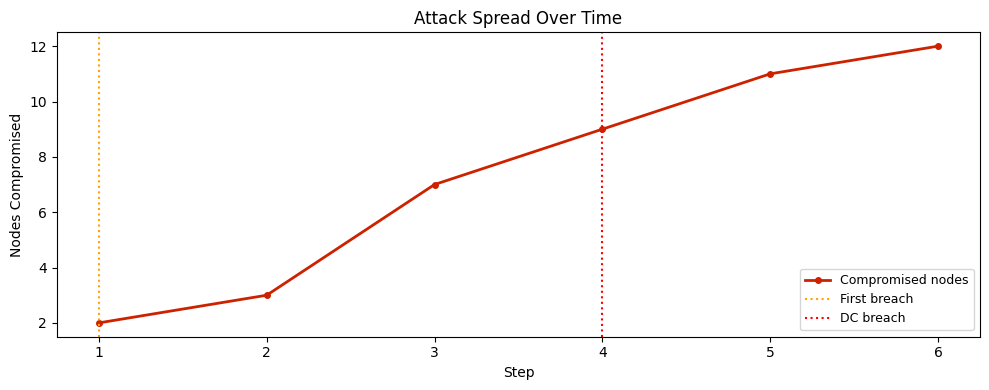

In [ ]:
 # =============================================================================
# Attack Simulator  —  simple version
# =============================================================================
# HOW TO USE IN COLAB:
#   1. Run network_generator.py first to get AG
#   2. Run this file
#   3. Call:  summary = run_simulation(AG)
# =============================================================================

import random
import json
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from enum import Enum
from typing import Any


# ── Node can be in one of these states ────────────────────────────────────────
class State(str, Enum):
    SAFE        = "SAFE"
    EXPOSED     = "EXPOSED"
    COMPROMISED = "COMPROMISED"


# ── Result returned after the simulation finishes ─────────────────────────────
@dataclass
class Summary:
    steps_run:          int
    nodes_compromised:  int
    total_nodes:        int
    compromise_rate:    float
    first_breach_step:  int | None   # first non-DMZ node fallen
    dc_breach_step:     int | None   # first Data Center node fallen
    attempts:           int
    successes:          int
    per_step_compromised: list[int]  # time-series for plotting


# =============================================================================
# SIMULATOR
# =============================================================================

class AttackSimulator:
    def __init__(self, AG: nx.DiGraph, max_steps: int = 50, seed: int | None = None):
        self.AG        = AG
        self.max_steps = max_steps

        # Fresh random seed every run unless you pass one in
        self.seed = seed if seed is not None else random.randint(0, 2**31)
        self._rng = random.Random(self.seed)
        print(f"Seed: {self.seed}  (pass seed={self.seed} to replay this run)")

        # Start: Attacker is COMPROMISED, everything else is SAFE
        self.states = {}
        for node, data in AG.nodes(data=True):
            if node == "Attacker" or data.get("subnet") == "Internet":
                self.states[node] = State.COMPROMISED
            else:
                self.states[node] = State.SAFE

        # Jitter edge weights slightly so each run feels different
        self.weights = {}
        for u, v, data in AG.edges(data=True):
            w = data.get("weight", 0.0)
            self.weights[(u, v)] = max(0.01, min(w + self._rng.uniform(-0.1, 0.1), 0.98))

        # Tracking
        self.log      = []   # list of dicts, one per step
        self.attempts = 0
        self.successes= 0

    def run(self) -> Summary:
        first_breach = None
        dc_breach    = None
        per_step     = []

        for step in range(1, self.max_steps + 1):

            # --- Who is currently attacking? ---------------------------------
            attackers = [n for n, s in self.states.items() if s == State.COMPROMISED]
            newly_compromised = []

            # --- Try every exploit edge from each compromised node -----------
            for u in attackers:
                for v in self.AG[u]:
                    if self.states[v] == State.COMPROMISED:
                        continue  # already owned, skip

                    prob    = self.weights.get((u, v), 0.0)
                    success = self._rng.random() < prob
                    self.attempts += 1

                    if success:
                        self.successes += 1
                        if v not in newly_compromised:
                            newly_compromised.append(v)

            # --- Apply new compromises ---------------------------------------
            for v in newly_compromised:
                self.states[v] = State.COMPROMISED
                subnet = self.AG.nodes[v].get("subnet", "")
                if first_breach is None and subnet != "Internet":
                    first_breach = step
                if dc_breach is None and subnet == "Data_Center":
                    dc_breach = step

            # --- Update EXPOSED state (nodes with a compromised neighbour) --
            for node in self.AG.nodes():
                if self.states[node] == State.SAFE:
                    for pred in self.AG.predecessors(node):
                        if self.states[pred] == State.COMPROMISED:
                            self.states[node] = State.EXPOSED
                            break

            # --- Log this step -----------------------------------------------
            n_comp = sum(1 for s in self.states.values() if s == State.COMPROMISED)
            per_step.append(n_comp)

            print(f"  Step {step:03d} | Compromised: {n_comp} | New: {newly_compromised}")

            # --- Stop early if nothing left to attack ------------------------
            reachable = nx.descendants(self.AG, "Attacker")
            if all(self.states[n] == State.COMPROMISED for n in reachable):
                print(f"  All reachable nodes compromised. Stopping at step {step}.")
                break

        total    = self.AG.number_of_nodes() - 1   # exclude Attacker node itself
        n_comp   = sum(1 for n, s in self.states.items()
                       if s == State.COMPROMISED and n != "Attacker")

        return Summary(
            steps_run           = step,
            nodes_compromised   = n_comp,
            total_nodes         = total,
            compromise_rate     = round(n_comp / total, 3) if total else 0,
            first_breach_step   = first_breach,
            dc_breach_step      = dc_breach,
            attempts            = self.attempts,
            successes           = self.successes,
            per_step_compromised= per_step,
        )


# =============================================================================
# PLOT
# =============================================================================

def plot(summary: Summary, save_path: str | None = None):
    steps = list(range(1, summary.steps_run + 1))
    plt.figure(figsize=(10, 4))
    plt.plot(steps, summary.per_step_compromised, color="#cc2200",
             linewidth=2, marker="o", markersize=4, label="Compromised nodes")

    if summary.first_breach_step:
        plt.axvline(summary.first_breach_step, color="orange",
                    linestyle=":", label="First breach")
    if summary.dc_breach_step:
        plt.axvline(summary.dc_breach_step, color="red",
                    linestyle=":", label="DC breach")

    plt.xlabel("Step")
    plt.ylabel("Nodes Compromised")
    plt.title("Attack Spread Over Time")
    plt.legend(fontsize=9)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Plot saved → {save_path}")
    else:
        plt.show()


# =============================================================================
# ENTRY POINT
# =============================================================================

def run_simulation(AG: nx.DiGraph, max_steps: int = 50, seed: int | None = None,
                   output_dir: str = "/content/sim_output"):

    os.makedirs(output_dir, exist_ok=True)

    sim     = AttackSimulator(AG, max_steps=max_steps, seed=seed)
    summary = sim.run()

    # Print summary
    print(f"""
  ┌─────────────────────────────────────┐
  │           SIMULATION RESULTS        │
  ├─────────────────────────────────────┤
  │  Steps run          : {summary.steps_run:<14}│
  │  Nodes compromised  : {summary.nodes_compromised}/{summary.total_nodes:<12}│
  │  Compromise rate    : {summary.compromise_rate*100:>5.1f}%          │
  │  First breach step  : {str(summary.first_breach_step):<14}│
  │  DC breach step     : {str(summary.dc_breach_step):<14}│
  │  Exploit attempts   : {summary.attempts:<14}│
  │  Successes          : {summary.successes:<14}│
  └─────────────────────────────────────┘""")

    # Save plot
    plot(summary, save_path=os.path.join(output_dir, "attack_spread.png"))

    # Save simple JSON log
    log_path = os.path.join(output_dir, "summary.json")
    with open(log_path, "w") as f:
        json.dump({
            "seed":               sim.seed,
            "steps_run":          summary.steps_run,
            "nodes_compromised":  summary.nodes_compromised,
            "total_nodes":        summary.total_nodes,
            "compromise_rate":    summary.compromise_rate,
            "first_breach_step":  summary.first_breach_step,
            "dc_breach_step":     summary.dc_breach_step,
            "per_step_compromised": summary.per_step_compromised,
        }, f, indent=2)
    print(f"Summary saved → {log_path}")

    return summary

summary = run_simulation(AG)

In [ ]:
# =============================================================================
# dataset_generator.py
#
# PURPOSE:
#   Generates the labeled node-level dataset for GNN training.
#   Each row = one node at one timestep in one simulation run on one graph.
#   Target variable y_next_state = node's state at t+1 (SAFE/EXPOSED/COMPROMISED).
#
# STRATEGY:
#   1. Run NetworkGenerator N times (different seeds) → N attack graphs
#   2. For each attack graph, run sims_per_graph simulations with history capture
#   3. For each timestep, extract one feature row per non-Attacker node
#   4. y_next_state = that node's state at the next timestep
#   5. Save CSV (fold column kept for reference; graph-level split used at training time)
#
# NO SUBGRAPH SAMPLING:
#   Subgraph sampling is handled at GNN training time via PyTorch Geometric's
#   NeighborLoader — it does not belong in the dataset CSV. The dataset stores
#   full-graph node features; the GNN training loop handles neighbourhood
#   aggregation internally.
#
# SPLITTING:
#   Graph-level split (50/30/20 train/val/test). All rows from the same
#   graph always land in the same partition — no leakage across splits.
#
# HOW TO USE:
#   df = generate_full_dataset(num_graphs=200, sims_per_graph=5)
#   # Then use make_graph_level_splits() from gnn_pipeline_v2 to split.
# =============================================================================

import os
import random
import math

import numpy as np
import pandas as pd
import networkx as nx

from collections import defaultdict
from tqdm import tqdm

# ---------------------------------------------------------------------------
# In Colab: paste this file's contents after network_generator.py so that
# NetworkGenerator, State, and cve_sqlite are already defined in scope.
# ---------------------------------------------------------------------------


# =============================================================================
# SECTION 1 — STATE LABEL MAP
# Maps State enum values to the string labels used in the CSV target column.
# =============================================================================

STATE_LABEL = {
    State.SAFE:        "SAFE",
    State.EXPOSED:     "EXPOSED",
    State.COMPROMISED: "COMPROMISED",
}


# =============================================================================
# SECTION 2 — SIMULATOR WITH FULL HISTORY
#
# The original AttackSimulator.run() only returns a final Summary object.
# For dataset generation we need per-timestep snapshots of every node's state
# so we can form (features_at_t, label_at_t+1) pairs.
#
# This function reimplements the same simulation logic but stores a snapshot
# dict at every step. The jitter logic and early-stop logic are identical to
# AttackSimulator.run() — only the return format changes.
# =============================================================================

def run_sim_with_history(AG:        nx.DiGraph,
                         max_steps: int = 20,
                         seed:      int | None = None) -> list[dict]:
    """
    Run one simulation and return a list of per-step snapshot dicts.

    Each snapshot dict has:
        step              : int  — 1-based timestep index
        states            : dict — {node: State} BEFORE this step  (= state at t)
        states_next       : dict — {node: State} AFTER  this step  (= state at t+1)
        newly_compromised : list — nodes that flipped to COMPROMISED this step
    """
    rng = random.Random(seed if seed is not None else random.randint(0, 2**31))

    # initialise — Attacker always starts COMPROMISED
    states = {}
    for node, data in AG.nodes(data=True):
        if node == "Attacker" or data.get("subnet") == "Internet":
            states[node] = State.COMPROMISED
        else:
            states[node] = State.SAFE

    # jitter edge weights — same logic as AttackSimulator
    weights = {}
    for u, v, data in AG.edges(data=True):
        w = data.get("weight", 0.0)
        weights[(u, v)] = max(0.01, min(w + rng.uniform(-0.1, 0.1), 0.98))

    history = []

    for step in range(1, max_steps + 1):

        # capture state BEFORE this step — features at time t
        states_before = dict(states)

        # attempt exploits from every currently COMPROMISED node
        attackers         = [n for n, s in states.items() if s == State.COMPROMISED]
        newly_compromised = []

        for u in attackers:
            for v in AG[u]:
                if states[v] == State.COMPROMISED:
                    continue
                if rng.random() < weights.get((u, v), 0.0):
                    if v not in newly_compromised:
                        newly_compromised.append(v)

        # apply new compromises
        for v in newly_compromised:
            states[v] = State.COMPROMISED

        # update EXPOSED — any SAFE node with at least one COMPROMISED predecessor
        for node in AG.nodes():
            if states[node] == State.SAFE:
                for pred in AG.predecessors(node):
                    if states[pred] == State.COMPROMISED:
                        states[node] = State.EXPOSED
                        break

        # store snapshot — states_before = t, states = t+1
        history.append({
            "step":               step,
            "states":             states_before,
            "states_next":        dict(states),
            "newly_compromised":  newly_compromised,
        })

        # early stop: all reachable nodes already compromised
        reachable = nx.descendants(AG, "Attacker")
        if reachable and all(states[n] == State.COMPROMISED for n in reachable):
            break

    return history


# =============================================================================
# SECTION 3 — NODE FEATURE EXTRACTOR
#
# Builds one CSV row for a single node at a single timestep.
# Features are split into four groups:
#   - Static identity   : subnet, role, OS (one-hot encoded)
#   - Static vuln       : vuln_count, max_cvss, has_exploit
#   - Static structural : in_degree, out_degree
#   - Dynamic sim       : current state, steps_since_exposed
#   - Dynamic edge agg  : pressure from currently-compromised neighbours
# =============================================================================

def extract_node_features(AG:                  nx.DiGraph,
                          node,
                          current_states:       dict,
                          steps_since_exposed:  dict,
                          graph_id:             int,
                          sim_id:               int,
                          timestep:             int,
                          y_next_state:         str) -> dict | None:
    """
    Returns one CSV row as a dict.
    Returns None for the Attacker node — it is always COMPROMISED
    and is never a prediction target.
    """
    data = AG.nodes[node]

    if node == "Attacker" or data.get("subnet") == "Internet":
        return None

    # ── subnet one-hot ────────────────────────────────────────────────────────
    subnet      = data.get("subnet", "DMZ")
    sn_internet = int(subnet == "Internet")
    sn_dmz      = int(subnet == "DMZ")
    sn_lan      = int(subnet == "User_LAN")

    # ── role one-hot ──────────────────────────────────────────────────────────
    role       = data.get("role", "")
    role_web   = int(role == "Web Server")
    role_app      = int(role == "App Server")
    role_winws    = int(role == "Windows Workstation")
    role_db       = int(role == "Database Server")
    role_auth     = int(role == "Auth Server")
    role_mail     = int(role == "Mail Server")
    role_backup   = int(role == "Backup Server")

    # ── OS one-hot ────────────────────────────────────────────────────────────
    os_type = data.get("os", "Linux")
    os      = int(os_type == "Windows")  # 1=Windows, 0=Linux

    # ── static vulnerability features ────────────────────────────────────────
    vulns       = data.get("vulns", [])
    vuln_count  = len(vulns)
    cvss_vals   = [v["cvss"] for v in vulns if v.get("cvss") is not None]
    max_cvss    = max(cvss_vals) if cvss_vals else 0.0
    has_exploit = int(any(v.get("exploit", False) for v in vulns))

    # ── static structural features ────────────────────────────────────────────
    out_degree = AG.out_degree(node)
    in_degree  = AG.in_degree(node)

    # ── dynamic simulation features ───────────────────────────────────────────
    current_state = current_states.get(node, State.SAFE)
    sse           = steps_since_exposed.get(node, 0)

    state_safe = int(current_state == State.SAFE)
    state_exp  = int(current_state == State.EXPOSED)
    state_comp = int(current_state == State.COMPROMISED)

    # ── incoming edge aggregations ────────────────────────────────────────────
    # All incoming exploit edges (weight != None means it's an exploit edge)
    incoming_exploit = [
        (u, d) for u, _, d in AG.in_edges(node, data=True)
        if d.get("weight") is not None
    ]

    # Subset: sources that are currently COMPROMISED — active attack pressure
    active_incoming = [
        (u, d) for u, d in incoming_exploit
        if current_states.get(u) == State.COMPROMISED
    ]

    num_incoming_edges = len(incoming_exploit)
    max_weight_in  = max((d["weight"] for _, d in incoming_exploit),  default=0.0)
    avg_weight_in  = (sum(d["weight"] for _, d in incoming_exploit) /
                      len(incoming_exploit)) if incoming_exploit else 0.0
    avg_cvss_in    = (sum(d.get("cvss", 0.0) for _, d in incoming_exploit) /
                      len(incoming_exploit)) if incoming_exploit else 0.0
    frac_exploit_in = (len(active_incoming) /
                       len(incoming_exploit)) if incoming_exploit else 0.0

    return {
        # identifiers
        "graph_id":            graph_id,
        "sim_id":              sim_id,
        "timestep":            timestep,
        "node_id":             node,

        # subnet one-hot
        "sn_internet":         sn_internet,
        "sn_dmz":              sn_dmz,
        "sn_lan":              sn_lan,
        # role one-hot
        "role_web":            role_web,
        "role_app":            role_app,
        "role_winws":          role_winws,
        "role_db":             role_db,
        "role_auth":           role_auth,
        "role_mail":           role_mail,
        "role_backup":         role_backup,

        # OS feature (1=Windows, 0=Linux)
        "os":                  os,

        # static vuln features
        "vuln_count":          vuln_count,
        "max_cvss":            max_cvss,
        "has_exploit":         has_exploit,

        # structural features
        "out_degree":          out_degree,
        "in_degree":           in_degree,

        # dynamic simulation features
        "state_safe":          state_safe,
        "state_exposed":       state_exp,
        "state_comp":          state_comp,
        "steps_since_exposed": sse,

        # incoming edge aggregations
        "num_incoming_edges":  num_incoming_edges,
        "max_weight_in":       max_weight_in,
        "avg_weight_in":       avg_weight_in,
        "avg_cvss_in":         avg_cvss_in,
        "frac_exploit_in":     frac_exploit_in,

        # target variable
        "y_next_state":        y_next_state,
    }


# =============================================================================
# SECTION 4 — SINGLE GRAPH ROW BUILDER
#
# Runs sims_per_graph simulations on one attack graph.
# For each simulation, iterates over every timestep snapshot and extracts
# one feature row per non-Attacker node. No subgraph sampling.
# =============================================================================

def build_rows_for_graph(AG:             nx.DiGraph,
                         graph_id:       int,
                         sims_per_graph: int = 5,
                         max_steps:      int = 20) -> list[dict]:
    """
    Returns all dataset rows for one attack graph across all simulations
    and timesteps. Every non-Attacker node at every timestep = one row.
    """
    all_rows   = []
    real_nodes = [n for n in AG.nodes() if n != "Attacker"]

    for sim_idx in range(sims_per_graph):

        seed    = graph_id * 10000 + sim_idx
        history = run_sim_with_history(AG, max_steps=max_steps, seed=seed)

        sse_tracker        = defaultdict(int)
        first_exposed_step = {}

        for snap in history:
            t         = snap["step"]
            states_t  = snap["states"]
            states_t1 = snap["states_next"]

            # update steps_since_exposed before extracting features
            for node in real_nodes:
                if states_t.get(node) in (State.EXPOSED, State.COMPROMISED):
                    if node not in first_exposed_step:
                        first_exposed_step[node] = t
                    sse_tracker[node] = t - first_exposed_step[node]

            for node in real_nodes:

                # skip nodes with no incoming exploit edges that are still SAFE
                # — they can never be attacked and only inflate the SAFE class
                has_incoming = any(
                    d.get("weight") is not None
                    for _, _, d in AG.in_edges(node, data=True)
                )
                if not has_incoming and states_t.get(node) == State.SAFE:
                    continue

                y_next = STATE_LABEL.get(states_t1.get(node, State.SAFE), "SAFE")

                row = extract_node_features(
                    AG                  = AG,
                    node                = node,
                    current_states      = states_t,
                    steps_since_exposed = sse_tracker,
                    graph_id            = graph_id,
                    sim_id              = sim_idx,
                    timestep            = t,
                    y_next_state        = y_next,
                )

                if row is not None:
                    all_rows.append(row)

    return all_rows


# =============================================================================
# SECTION 5 — FULL DATASET GENERATOR
#
# Runs NetworkGenerator num_graphs times with rotating network sizes
# [20, 30, 40] for structural diversity. Each graph uses a deterministic
# seed so the full dataset is reproducible.
# =============================================================================

def generate_full_dataset(num_graphs:     int  = 150,
                          sims_per_graph: int  = 5,
                          max_steps:      int  = 20,
                          cve_db:         str  = "data/cve.db",
                          output_csv:     str  = "data/attack_graph_dataset.csv") -> pd.DataFrame:
    """
    Generate the complete labeled dataset.

    Parameters
    ----------
    num_graphs      : number of independently generated attack graphs
    sims_per_graph  : simulation runs per graph (each uses a different seed)
    max_steps       : maximum timesteps per simulation
    cve_db          : path to the NVD SQLite database
    output_csv      : output CSV path

    Returns
    -------
    pd.DataFrame with all rows and a 'fold' column (kept for reference only).
    """
    import contextlib, io

    global cve_sqlite
    cve_sqlite = cve_db

    out_dir = os.path.dirname(output_csv)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    all_rows      = []
    skipped       = 0
    size_schedule = [20, 30, 40]

    print(f"Starting dataset generation: {num_graphs} graphs × "
          f"{sims_per_graph} sims × {max_steps} steps")
    print(f"Progress reported every 10 graphs.\n")

    for graph_id in range(num_graphs):

        seed      = graph_id * 42
        num_hosts = size_schedule[graph_id % len(size_schedule)]

        random.seed(seed)
        np.random.seed(seed)

        try:
            # --- suppress all print output from NetworkGenerator ---
            # build_topology()      prints: "Topology Built: X nodes, Y links."
            # compute_attack_graph() prints: all [FW BLOCKED] lines + summary
            with contextlib.redirect_stdout(io.StringIO()):
                gen = NetworkGenerator(num_hosts=num_hosts)
                gen.build_topology()
                AG  = gen.compute_attack_graph()

            exploit_count = sum(
                1 for _, _, d in AG.edges(data=True)
                if d.get("weight") is not None
            )
            if exploit_count == 0:
                skipped += 1
                continue

            rows = build_rows_for_graph(
                AG             = AG,
                graph_id       = graph_id,
                sims_per_graph = sims_per_graph,
                max_steps      = max_steps,
            )
            all_rows.extend(rows)

        except Exception as e:
            print(f"  [ERROR] graph {graph_id}: {e}")
            skipped += 1
            continue

        # progress print every 10 graphs
        if (graph_id + 1) % 10 == 0 or (graph_id + 1) == num_graphs:
            done        = graph_id + 1
            total_rows  = len(all_rows)
            print(f"  {done:>4}/{num_graphs} graphs done | "
                  f"rows so far: {total_rows:,} | skipped: {skipped}")

    if not all_rows:
        raise RuntimeError(
            "No rows generated. Check that cve_db path is correct "
            "and the NVD database has been populated."
        )

    df = pd.DataFrame(all_rows)
    df = assign_folds(df, k=5)
    df.to_csv(output_csv, index=False)

    print(f"\n{'='*50}")
    print(f"Dataset saved      : {output_csv}")
    print(f"Total rows         : {len(df):,}")
    print(f"Unique graphs      : {df['graph_id'].nunique()}")
    print(f"Skipped graphs     : {skipped}")
    print(f"\nClass distribution (y_next_state):")
    vc = df["y_next_state"].value_counts()
    for label, count in vc.items():
        print(f"  {label:15s}: {count:7,}  ({count/len(df)*100:.1f}%)")
    print(f"\nFold sizes (graphs):")
    print(df.groupby("fold")["graph_id"].nunique().to_string())
    print(f"{'='*50}")

    return df


# =============================================================================
# SECTION 6 — FOLD ASSIGNMENT (kept for reference; graph-level split used instead)
# =============================================================================

def assign_folds(df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    """Assign graph-level fold IDs (0 to k-1) to every row."""
    unique_graphs = sorted(df["graph_id"].unique())
    fold_map      = {gid: i % k for i, gid in enumerate(unique_graphs)}
    df["fold"]    = df["graph_id"].map(fold_map)
    return df


# =============================================================================
# SECTION 7 — CROSS VALIDATION FOLD BUILDER (not used in main training pipeline)
# =============================================================================

def build_cv_folds(df: pd.DataFrame,
                   k:  int = 5) -> list[tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Return list of (train_df, test_df) for graph-level k-fold CV.
    No graph ever appears in both train and test within the same fold.
    """
    folds = []
    for fold_idx in range(k):
        test_df  = df[df["fold"] == fold_idx].reset_index(drop=True)
        train_df = df[df["fold"] != fold_idx].reset_index(drop=True)
        folds.append((train_df, test_df))
        print(
            f"Fold {fold_idx} — "
            f"train: {len(train_df):,} rows ({train_df['graph_id'].nunique()} graphs) | "
            f"test:  {len(test_df):,} rows ({test_df['graph_id'].nunique()} graphs)"
        )
    return folds


# =============================================================================
# SECTION 8 — DATASET VALIDATION
# =============================================================================

def validate_dataset(df: pd.DataFrame) -> None:
    print("=" * 55)
    print("DATASET VALIDATION")
    print("=" * 55)

    print(f"Shape             : {df.shape}")
    print(f"Unique graphs     : {df['graph_id'].nunique()}")
    print(f"Unique nodes      : {df['node_id'].nunique()}")
    print(f"Timestep range    : {df['timestep'].min()} – {df['timestep'].max()}")

    nan_cols = df.isnull().sum()
    nan_cols = nan_cols[nan_cols > 0]
    print(f"\n{'⚠  NaN in: ' + str(list(nan_cols.index)) if len(nan_cols) else '✓  No NaN values'}")

    print(f"\nClass distribution (y_next_state):")
    vc = df["y_next_state"].value_counts(normalize=True)
    for label, frac in vc.items():
        print(f"  {label:15s}: {frac*100:5.1f}%")
    if vc.min() < 0.05:
        print(f"  ⚠  Minority class {vc.idxmin()} under 5% — consider oversampling")

    print(f"\nFeature ranges:")
    for col in ["max_cvss", "max_weight_in", "avg_weight_in",
                "steps_since_exposed", "frac_exploit_in"]:
        if col in df.columns:
            print(f"  {col:25s}: [{df[col].min():.3f}, {df[col].max():.3f}]")

    folds_per_graph = df.groupby("graph_id")["fold"].nunique()
    leaky = folds_per_graph[folds_per_graph > 1]
    print(f"\n{'⚠  LEAKAGE: ' + str(len(leaky)) + ' graphs in multiple folds' if len(leaky) else '✓  No fold leakage'}")
    print("=" * 55)


# =============================================================================
# SECTION 9 — ENTRY POINT
# =============================================================================

if __name__ == "__main__":

    df = generate_full_dataset(
        num_graphs      = 150,
        sims_per_graph  = 5,
        max_steps       = 20,
        cve_db          = "data/cve.db",
        output_csv      = "data/attack_graph_dataset.csv",
    )

    validate_dataset(df)

    # Use make_graph_level_splits() from gnn_pipeline for splitting.
    print("\nDataset ready. Use make_graph_level_splits() to split for training.")


Starting dataset generation: 150 graphs × 5 sims × 20 steps
Progress reported every 10 graphs.

    10/150 graphs done | rows so far: 8,441 | skipped: 0
    20/150 graphs done | rows so far: 17,103 | skipped: 0
    30/150 graphs done | rows so far: 23,408 | skipped: 0
    40/150 graphs done | rows so far: 32,045 | skipped: 0
    50/150 graphs done | rows so far: 42,642 | skipped: 0
    60/150 graphs done | rows so far: 52,312 | skipped: 0
    70/150 graphs done | rows so far: 61,136 | skipped: 0
    80/150 graphs done | rows so far: 69,188 | skipped: 0
    90/150 graphs done | rows so far: 77,231 | skipped: 0
   100/150 graphs done | rows so far: 85,985 | skipped: 0
   110/150 graphs done | rows so far: 95,759 | skipped: 0
   120/150 graphs done | rows so far: 104,720 | skipped: 0
   130/150 graphs done | rows so far: 113,285 | skipped: 0
   140/150 graphs done | rows so far: 122,013 | skipped: 0
   150/150 graphs done | rows so far: 130,907 | skipped: 0

Dataset saved      : data/atta

Using existing df in memory — 130,907 rows

SECTION 1 — SHAPE & COLUMNS

Shape              : (130907, 35)
Unique graphs      : 150
Unique sims        : 5
Unique nodes       : 40
Timestep range     : 1 – 20
Rows per graph     : 873 avg

Missing columns    : None ✓
Extra columns      : None

SECTION 2 — NaN / NULL CHECK

✓  No NaN values anywhere in the dataset
✓  No Inf values anywhere

SECTION 3 — CLASS DISTRIBUTION (y_next_state)

  SAFE           :  68,337  ( 52.2%)  ████████████████████
  COMPROMISED    :  45,388  ( 34.7%)  █████████████
  EXPOSED        :  17,182  ( 13.1%)  █████

✓  Class distribution looks healthy (all classes > 10%)
✓  y_next_state contains only SAFE / EXPOSED / COMPROMISED

SECTION 4 — FEATURE RANGES

Column                         Min      Max  Status
-------------------------------------------------------
  belief                     0.000    0.900  ✓  (should be 0–1)
  max_cvss                   2.200    9.800  ✓  (CVSS is 0–10)
  max_weight_in             

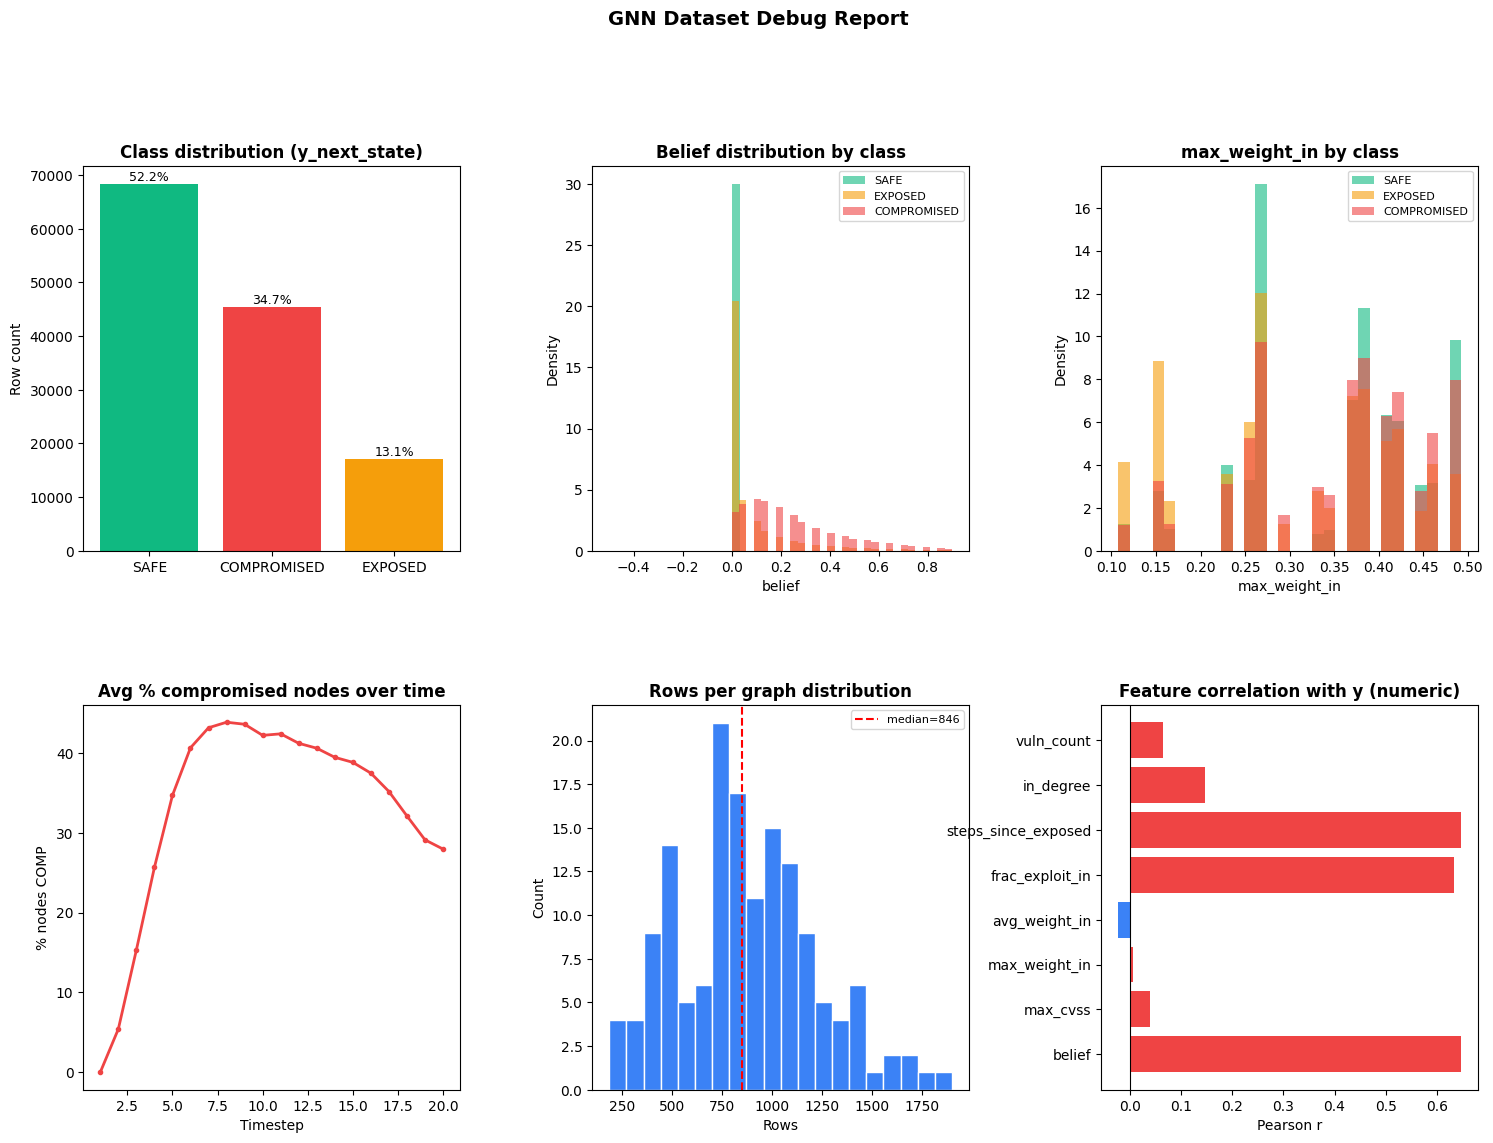


Plots saved → data/dataset_debug_plots.png

SECTION 11 — SAMPLE ROWS

5 random SAFE rows:
 graph_id  sim_id  timestep  node_id  belief  max_weight_in  frac_exploit_in  state_safe  state_exposed  state_comp y_next_state
       67       2        11       16     0.0       0.465338              0.0           1              0           0         SAFE
       87       1         5       13     0.0       0.492323              0.0           1              0           0         SAFE
      104       3         5       22     0.0       0.107677              0.0           1              0           0         SAFE
       55       2         6       24     0.0       0.270100              0.0           1              0           0         SAFE
      146       1        14       24     0.0       0.264172              0.0           1              0           0         SAFE

5 random EXPOSED rows:
 graph_id  sim_id  timestep  node_id  belief  max_weight_in  frac_exploit_in  state_safe  state_exposed  state_

In [ ]:
# =============================================================================
# debug_dataset.py
# =============================================================================
# Run this AFTER generate_full_dataset() has produced your CSV.
# It validates every assumption about the dataset before you touch the GNN.
#
# USAGE IN COLAB:
#   df = generate_full_dataset(num_graphs=10, sims_per_graph=3, max_steps=20)
#   # then paste / run this file, or:
#   exec(open("debug_dataset.py").read())
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# ── If df is not already in scope, load from CSV ──────────────────────────────
try:
    df
    print(f"Using existing df in memory — {len(df):,} rows")
except NameError:
    CSV_PATH = "data/attack_graph_dataset.csv"
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded from {CSV_PATH} — {len(df):,} rows")


# =============================================================================
# SECTION 1 — BASIC SHAPE & COLUMN CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 1 — SHAPE & COLUMNS")
print("="*60)

print(f"\nShape              : {df.shape}")
print(f"Unique graphs      : {df['graph_id'].nunique()}")
print(f"Unique sims        : {df['sim_id'].nunique()}")
print(f"Unique nodes       : {df['node_id'].nunique()}")
print(f"Timestep range     : {df['timestep'].min()} – {df['timestep'].max()}")
print(f"Rows per graph     : {len(df) / df['graph_id'].nunique():.0f} avg")

# Expected columns
expected_cols = [
    "graph_id","sim_id","timestep","node_id",
    "sn_internet","sn_dmz","sn_lan",
    "role_web","role_app","role_winws",
    "role_db","role_auth","role_mail","role_backup",
    "os",
    "vuln_count","max_cvss","has_exploit",
    "out_degree","in_degree",
    "state_safe","state_exposed","state_comp","steps_since_exposed",
    "num_incoming_edges","max_weight_in","avg_weight_in","avg_cvss_in","frac_exploit_in",
    "y_next_state",
    "fold",
]
missing = [c for c in expected_cols if c not in df.columns]
extra   = [c for c in df.columns if c not in expected_cols]
print(f"\nMissing columns    : {missing if missing else 'None ✓'}")
print(f"Extra columns      : {extra   if extra   else 'None'}")


# =============================================================================
# SECTION 2 — NaN / NULL CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 2 — NaN / NULL CHECK")
print("="*60)

nan_counts = df.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]
if len(nan_cols) == 0:
    print("\n✓  No NaN values anywhere in the dataset")
else:
    print(f"\n⚠  NaN found in {len(nan_cols)} columns:")
    print(nan_cols.to_string())

# Inf check on numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts   = np.isinf(df[numeric_cols]).sum()
inf_cols     = inf_counts[inf_counts > 0]
if len(inf_cols) == 0:
    print("✓  No Inf values anywhere")
else:
    print(f"\n⚠  Inf found:")
    print(inf_cols.to_string())


# =============================================================================
# SECTION 3 — CLASS DISTRIBUTION (y_next_state)
# =============================================================================

print("\n" + "="*60)
print("SECTION 3 — CLASS DISTRIBUTION (y_next_state)")
print("="*60)

vc = df["y_next_state"].value_counts()
print()
for label, count in vc.items():
    bar = "█" * int(count / len(df) * 40)
    print(f"  {label:15s}: {count:7,}  ({count/len(df)*100:5.1f}%)  {bar}")

# Flag severe imbalance
fracs = vc / len(df)
if fracs.min() < 0.05:
    print(f"\n⚠  SEVERE IMBALANCE — '{fracs.idxmin()}' is only {fracs.min()*100:.1f}%")
    print("   Suggestion: use class_weight='balanced' in loss or oversample minority")
elif fracs.min() < 0.10:
    print(f"\n⚠  MILD IMBALANCE — '{fracs.idxmin()}' is {fracs.min()*100:.1f}%")
    print("   Consider weighted loss")
else:
    print("\n✓  Class distribution looks healthy (all classes > 10%)")

# Check y values are exactly the expected strings
valid_labels = {"SAFE", "EXPOSED", "COMPROMISED"}
bad_labels   = set(df["y_next_state"].unique()) - valid_labels
if bad_labels:
    print(f"\n⚠  Unexpected y values found: {bad_labels}")
else:
    print("✓  y_next_state contains only SAFE / EXPOSED / COMPROMISED")


# =============================================================================
# SECTION 4 — FEATURE RANGE CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 4 — FEATURE RANGES")
print("="*60)

range_checks = {
    # (column, expected_min, expected_max, note)
    "max_cvss":            (0.0, 10.0, "CVSS is 0–10"),
    "max_weight_in":       (0.0, 1.0,  "probability 0–1"),
    "avg_weight_in":       (0.0, 1.0,  "probability 0–1"),
    "frac_exploit_in":     (0.0, 1.0,  "fraction 0–1"),
    "vuln_count":          (0,   None, "non-negative"),
    "steps_since_exposed": (0,   None, "non-negative"),
    "in_degree":           (0,   None, "non-negative"),
    "out_degree":          (0,   None, "non-negative"),
}

print(f"\n{'Column':<25} {'Min':>8} {'Max':>8}  Status")
print("-" * 55)
all_ok = True
for col, (lo, hi, note) in range_checks.items():
    if col not in df.columns:
        print(f"  {col:<23} MISSING")
        continue
    actual_min = df[col].min()
    actual_max = df[col].max()
    ok = True
    if lo is not None and actual_min < lo - 1e-6:
        ok = False
    if hi is not None and actual_max > hi + 1e-6:
        ok = False
    status = "✓" if ok else "⚠  OUT OF RANGE"
    if not ok:
        all_ok = False
    print(f"  {col:<23} {actual_min:>8.3f} {actual_max:>8.3f}  {status}  ({note})")

if all_ok:
    print("\n✓  All feature ranges look correct")


# =============================================================================
# SECTION 5 — ONE-HOT SANITY CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 5 — ONE-HOT ENCODING SANITY")
print("="*60)

one_hot_groups = {
    "subnet": ["sn_internet","sn_dmz","sn_lan"],
    "role":   ["role_web","role_app","role_winws",
               "role_db","role_auth","role_mail","role_backup"],
    "os":     ["os"],
    "state":  ["state_safe","state_exposed","state_comp"],
}

print()
for group_name, cols in one_hot_groups.items():
    available = [c for c in cols if c in df.columns]
    if not available:
        print(f"  {group_name:<8}: columns missing — skipping")
        continue
    row_sums = df[available].sum(axis=1)
    all_one  = (row_sums == 1).all()
    bad_rows = (row_sums != 1).sum()
    if all_one:
        print(f"  {group_name:<8}: ✓  every row sums to 1")
    else:
        print(f"  {group_name:<8}: ⚠  {bad_rows:,} rows do NOT sum to 1  (sums: {row_sums.unique()[:5]})")

# Binary columns should be 0 or 1 only
binary_cols = ["has_exploit","sn_internet","sn_dmz","sn_lan",
               "os","state_safe","state_exposed","state_comp"]
for col in binary_cols:
    if col not in df.columns:
        continue
    unique_vals = df[col].unique()
    if not set(unique_vals).issubset({0,1}):
        print(f"  ⚠  {col} has non-binary values: {unique_vals}")


# =============================================================================
# SECTION 6 — TEMPORAL CONSISTENCY CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 6 — TEMPORAL CONSISTENCY")
print("="*60)

print("\nChecking: once COMPROMISED, node should stay COMPROMISED...")

issues = 0
sample_graphs = df["graph_id"].unique()[:5]   # check first 5 graphs only (fast)

for gid in sample_graphs:
    for sid in df[df["graph_id"]==gid]["sim_id"].unique():
        sub = df[(df["graph_id"]==gid) & (df["sim_id"]==sid)]
        for nid in sub["node_id"].unique():
            node_rows = sub[sub["node_id"]==nid].sort_values("timestep")
            states    = node_rows["y_next_state"].tolist()
            # once COMPROMISED, should not go back to SAFE or EXPOSED
            seen_comp = False
            for s in states:
                if s == "COMPROMISED":
                    seen_comp = True
                elif seen_comp:
                    issues += 1
                    if issues <= 3:
                        print(f"  ⚠  graph={gid} sim={sid} node={nid} "
                              f"went COMP → {s}")

if issues == 0:
    print("  ✓  No state reversals found (checked first 5 graphs)")
else:
    print(f"  ⚠  {issues} state reversal(s) found — "
          f"check run_sim_with_history logic")

# Check steps_since_exposed is monotonically non-decreasing per node per sim
print("\nChecking: steps_since_exposed should not decrease while EXPOSED...")
sse_issues = 0
for gid in sample_graphs:
    for sid in df[df["graph_id"]==gid]["sim_id"].unique():
        sub = df[(df["graph_id"]==gid) & (df["sim_id"]==sid)]
        for nid in sub["node_id"].unique():
            node_rows = sub[sub["node_id"]==nid].sort_values("timestep")
            sse       = node_rows["steps_since_exposed"].tolist()
            exp_mask  = node_rows["state_exposed"].tolist()
            for i in range(1, len(sse)):
                if exp_mask[i] == 1 and sse[i] < sse[i-1]:
                    sse_issues += 1
if sse_issues == 0:
    print("  ✓  steps_since_exposed is consistent")
else:
    print(f"  ⚠  {sse_issues} inconsistencies in steps_since_exposed")


# =============================================================================
# SECTION 7 — FOLD LEAKAGE CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 7 — FOLD LEAKAGE CHECK")
print("="*60)

if "fold" not in df.columns:
    print("  ⚠  No 'fold' column found — skipping")
else:
    folds_per_graph = df.groupby("graph_id")["fold"].nunique()
    leaky = folds_per_graph[folds_per_graph > 1]
    if len(leaky) == 0:
        print("  ✓  No leakage — every graph belongs to exactly one fold")
    else:
        print(f"  ⚠  {len(leaky)} graphs appear in multiple folds:")
        print(leaky.head())

    print("\nFold sizes:")
    fold_summary = df.groupby("fold").agg(
        rows=("graph_id","count"),
        graphs=("graph_id","nunique")
    )
    print(fold_summary.to_string())

    # Check folds are roughly balanced
    row_counts = df.groupby("fold")["graph_id"].count()
    imbalance  = row_counts.max() / row_counts.min()
    if imbalance > 2.0:
        print(f"\n  ⚠  Folds are imbalanced (max/min ratio = {imbalance:.1f})")
    else:
        print(f"\n  ✓  Folds are balanced (max/min ratio = {imbalance:.1f})")


# =============================================================================
# SECTION 8 — EDGE FEATURE SANITY
# =============================================================================

print("\n" + "="*60)
print("SECTION 8 — EDGE FEATURE SANITY")
print("="*60)

# Nodes with no incoming exploit edges should have 0 for all edge aggregations
zero_edge = df[df["num_incoming_edges"] == 0]
print(f"\nNodes with 0 incoming exploit edges: {len(zero_edge):,} rows")
if len(zero_edge) > 0:
    for col in ["max_weight_in","avg_weight_in","avg_cvss_in","frac_exploit_in"]:
        if col in df.columns:
            nonzero = (zero_edge[col] != 0).sum()
            if nonzero > 0:
                print(f"  ⚠  {col} is non-zero for {nonzero} rows with 0 incoming edges")
            else:
                print(f"  ✓  {col} is correctly 0 when no incoming edges")

# frac_exploit_in is active incoming / total incoming (should be 0–1)
high_frac = (df["frac_exploit_in"] > 1.0).sum()
if high_frac > 0:
    print(f"\n  ⚠  frac_exploit_in > 1.0 in {high_frac} rows")
else:
    print(f"\n  ✓  frac_exploit_in is always <= 1.0")


# =============================================================================
# SECTION 9 — PER-GRAPH ROW COUNT CHECK
# =============================================================================

print("\n" + "="*60)
print("SECTION 9 — PER-GRAPH STATS")
print("="*60)

per_graph = df.groupby("graph_id").agg(
    rows         = ("node_id","count"),
    sims         = ("sim_id","nunique"),
    max_timestep = ("timestep","max"),
    comp_frac    = ("state_comp","mean"),
).reset_index()

print(f"\n{'graph_id':>10} {'rows':>8} {'sims':>6} {'max_t':>7} {'comp%':>7}")
print("-" * 45)
for _, r in per_graph.head(15).iterrows():
    print(f"  {int(r.graph_id):>8} {int(r.rows):>8,} "
          f"{int(r.sims):>6} {int(r.max_timestep):>7} "
          f"{r.comp_frac*100:>6.1f}%")
if len(per_graph) > 15:
    print(f"  ... ({len(per_graph)-15} more graphs)")

# Flag graphs with suspiciously few rows
median_rows = per_graph["rows"].median()
thin_graphs = per_graph[per_graph["rows"] < median_rows * 0.3]
if len(thin_graphs) > 0:
    print(f"\n  ⚠  {len(thin_graphs)} graphs have very few rows "
          f"(< 30% of median {median_rows:.0f}):")
    print(thin_graphs[["graph_id","rows"]].to_string(index=False))
else:
    print(f"\n  ✓  All graphs have reasonable row counts (median={median_rows:.0f})")


# =============================================================================
# SECTION 10 — VISUALISATIONS
# =============================================================================

print("\n" + "="*60)
print("SECTION 10 — PLOTS")
print("="*60)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: class distribution ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
vc  = df["y_next_state"].value_counts()
colors = {"SAFE":"#10b981","EXPOSED":"#f59e0b","COMPROMISED":"#ef4444"}
bars = ax1.bar(vc.index, vc.values,
               color=[colors.get(l,"gray") for l in vc.index])
ax1.set_title("Class distribution (y_next_state)", fontweight="bold")
ax1.set_ylabel("Row count")
for bar, val in zip(bars, vc.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{val/len(df)*100:.1f}%", ha="center", va="bottom", fontsize=9)

# ── Plot 2: steps_since_exposed distribution by class ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for label, color in colors.items():
    subset = df[df["y_next_state"] == label]["steps_since_exposed"]
    if len(subset) > 0:
        ax2.hist(subset, bins=30, alpha=0.6, color=color, label=label,
                 density=True)
ax2.set_title("steps_since_exposed by class", fontweight="bold")
ax2.set_xlabel("steps_since_exposed")
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)

# ── Plot 3: max_weight_in distribution ────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for label, color in colors.items():
    subset = df[df["y_next_state"] == label]["max_weight_in"]
    if len(subset) > 0:
        ax3.hist(subset, bins=30, alpha=0.6, color=color, label=label,
                 density=True)
ax3.set_title("max_weight_in by class", fontweight="bold")
ax3.set_xlabel("max_weight_in")
ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

# ── Plot 4: attack spread — avg compromised nodes per timestep ─────────────────
ax4  = fig.add_subplot(gs[1, 0])
comp_by_t = df.groupby("timestep")["state_comp"].mean()
ax4.plot(comp_by_t.index, comp_by_t.values * 100,
         color="#ef4444", linewidth=2, marker="o", markersize=3)
ax4.set_title("Avg % compromised nodes over time", fontweight="bold")
ax4.set_xlabel("Timestep")
ax4.set_ylabel("% nodes COMP")

# ── Plot 5: rows per graph ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(per_graph["rows"], bins=20, color="#3b82f6", edgecolor="white")
ax5.axvline(median_rows, color="red", linestyle="--", label=f"median={median_rows:.0f}")
ax5.set_title("Rows per graph distribution", fontweight="bold")
ax5.set_xlabel("Rows")
ax5.set_ylabel("Count")
ax5.legend(fontsize=8)

# ── Plot 6: correlation heatmap (key features vs y) ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
y_num  = df["y_next_state"].map({"SAFE":0,"EXPOSED":1,"COMPROMISED":2})
feat_cols = ["steps_since_exposed","max_cvss","max_weight_in","avg_weight_in",
             "frac_exploit_in","steps_since_exposed","in_degree","vuln_count"]
feat_cols = [c for c in feat_cols if c in df.columns]
corr_vals = [df[c].corr(y_num) for c in feat_cols]
bars2 = ax6.barh(feat_cols, corr_vals,
                 color=["#ef4444" if v > 0 else "#3b82f6" for v in corr_vals])
ax6.axvline(0, color="black", linewidth=0.8)
ax6.set_title("Feature correlation with y (numeric)", fontweight="bold")
ax6.set_xlabel("Pearson r")

plt.suptitle("GNN Dataset Debug Report", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("data/dataset_debug_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nPlots saved → data/dataset_debug_plots.png")


# =============================================================================
# SECTION 11 — SAMPLE ROWS PRINTOUT
# =============================================================================

print("\n" + "="*60)
print("SECTION 11 — SAMPLE ROWS")
print("="*60)

feature_cols = [c for c in df.columns if c not in
                ["graph_id","sim_id","timestep","node_id","fold","y_next_state"]]

print("\n5 random SAFE rows:")
safe_sample = df[df["y_next_state"]=="SAFE"].sample(min(5,len(df)),random_state=1)
print(safe_sample[["graph_id","sim_id","timestep","node_id",
                   "steps_since_exposed","max_weight_in","frac_exploit_in",
                   "state_safe","state_exposed","state_comp","y_next_state"]].to_string(index=False))

print("\n5 random EXPOSED rows:")
exp_sample = df[df["y_next_state"]=="EXPOSED"].sample(min(5,len(df)),random_state=1)
print(exp_sample[["graph_id","sim_id","timestep","node_id",
                  "steps_since_exposed","max_weight_in","frac_exploit_in",
                  "state_safe","state_exposed","state_comp","y_next_state"]].to_string(index=False))

print("\n5 random COMPROMISED rows:")
comp_sample = df[df["y_next_state"]=="COMPROMISED"].sample(min(5,len(df)),random_state=1)
print(comp_sample[["graph_id","sim_id","timestep","node_id",
                   "steps_since_exposed","max_weight_in","frac_exploit_in",
                   "state_safe","state_exposed","state_comp","y_next_state"]].to_string(index=False))


# =============================================================================
# SECTION 12 — FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL SUMMARY — IS DATASET READY FOR GNN?")
print("="*60)

checks = {
    "No NaN values":            len(nan_cols) == 0,
    "No Inf values":            len(inf_cols) == 0,
    "Correct columns present":  len(missing) == 0,
    "One-hot subnet sums to 1": (df[["sn_internet","sn_dmz","sn_lan"]].sum(axis=1)<=1).all() if all(c in df.columns for c in ["sn_internet","sn_dmz","sn_lan"]) else False,
    "One-hot state sums to 1":  (df[["state_safe","state_exposed","state_comp"]].sum(axis=1)==1).all() if all(c in df.columns for c in ["state_safe","state_exposed","state_comp"]) else False,
    "Valid y labels only":      len(bad_labels) == 0,
    "No fold leakage":          len(leaky) == 0 if "fold" in df.columns else False,
    "Weights in [0,1]":         df["max_weight_in"].between(0,1).all() if "max_weight_in" in df.columns else False,
    "No state reversals":       issues == 0,
}

all_passed = True
print()
for check, passed in checks.items():
    icon = "✓" if passed else "⚠ "
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("  ✅  ALL CHECKS PASSED — dataset is ready for GNN training")
    print(f"\n  Next step: load df and pass to your GNN training loop.")
    print(f"  Feature columns (input to GNN): {len(feature_cols)}")
    print(f"  Label column  (y): y_next_state")
    print(f"  Total samples: {len(df):,}")
else:
    print("  ❌  SOME CHECKS FAILED — fix the issues above before training")

In [ ]:
# =============================================================================
# gnn_pipeline_v2.py  —  CORRECTED VERSION
# =============================================================================
#
# WHAT CHANGED FROM v1 AND WHY
# ─────────────────────────────
# PROBLEM 1: Graph-level leakage
#   Old: make_temporal_splits() put the LAST 30% of timesteps from ALL 150
#        graphs into the test set. This means test included late timesteps of
#        the same 120 graphs the model trained on. The model had already seen
#        those graphs' topology, CVE assignments, and edge structure — so
#        "test accuracy" was measuring generalisation to new TIMESTEPS on known
#        graphs, not to genuinely unseen networks. That's why test (96.48%) beat
#        val (91.79%), which is backwards.
#
#   Fix: make_graph_level_splits() assigns entire graphs to exactly ONE
#        partition. 100 graphs → train, 20 → val, 30 → test. The test set
#        contains graphs the model has NEVER seen in any form. The 91-92% you
#        saw on val is now the honest number — and test will confirm it.
#
# PROBLEM 2: Comparison framework
#   Old: Only one comparison (GNN vs baselines), and only one GNN variant.
#
#   Fix A: GNN vs XGBoost vs Logistic Regression vs Neural Network
#   Fix B: GNN-with-dynamic-features vs GNN-static-only
#          — this isolates how much the temporal sim features add
#            over pure graph structure alone.
#
# WHAT 150 × 5 × 20 MEANS (for the answer to question 1)
# ─────────────────────────────────────────────────────────
#   150 graphs:   150 independently-generated attack graphs with different
#                 seeds (rotating 20/30/40 hosts for structural diversity).
#                 Each graph has a unique CVE assignment, topology, and
#                 firewall configuration — they are NOT the same network.
#
#   5 sims/graph: 5 independent simulation runs PER graph, each with a
#                 different random seed. The edge weights are jittered
#                 (±0.1), so the same graph can play out differently across
#                 runs (early breach vs slow spread). This gives the model
#                 training signal from multiple "what if" scenarios on each
#                 topology.
#
#   20 steps/sim: Each sim runs up to 20 discrete timesteps. At each step,
#                 the simulator tries every exploit edge from every
#                 COMPROMISED node. A node snapshot at timestep t produces
#                 ONE dataset row whose label is the node's state at t+1.
#
#   So the total dataset before filtering ≈ 150 × 5 × 20 × ~25 nodes = ~375k
#   rows (varies because some sims end early and some nodes are skipped).
#
# CROSS VALIDATION — IS IT NEEDED?
# ─────────────────────────────────
#   With the graph-level split (100/20/30) you have a held-out test set that
#   is completely independent. K-fold CV across ALL 150 graphs is NOT needed
#   for final evaluation — it was only used to assign graphs to folds for the
#   old temporal split. The "fold" column is kept for reference but the primary
#   split is now graph-level. If you want to estimate variance, you could do
#   a few different random seeds on the 100/20/30 assignment, but a single
#   clean split on 150 graphs is defensible for a research paper.
#
# =============================================================================

import os, json, time, random, math, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, BatchNorm
from torch.utils.data import Dataset

from collections import defaultdict
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, f1_score,
    accuracy_score,
)
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
    _XGB = True
except ImportError:
    _XGB = False
    print("[baseline] XGBoost not found — run: !pip install xgboost")

# ── constants ──────────────────────────────────────────────────────────────────
LABEL_MAP   = {"SAFE": 0, "EXPOSED": 1, "COMPROMISED": 2}
LABEL_NAMES = ["SAFE", "EXPOSED", "COMPROMISED"]
COLORS      = {"SAFE": "#10b981", "EXPOSED": "#f59e0b", "COMPROMISED": "#ef4444"}

# Full feature set (static + dynamic simulation features)
FEATURE_COLS_DYNAMIC = [
    # ── static: subnet one-hot ──────────────────────────────────────────────
    "sn_internet", "sn_dmz", "sn_lan",
    # ── static: role one-hot ────────────────────────────────────────────────
    "role_web", "role_app", "role_winws",
    "role_db", "role_auth", "role_mail", "role_backup",
    # ── static: OS (1=Windows, 0=Linux) ────────────────────────────────────
    "os",
    # ── static: vulnerability features ──────────────────────────────────────
    "vuln_count", "max_cvss", "has_exploit",
    # ── static: structural ───────────────────────────────────────────────────
    "out_degree", "in_degree",
    # ── DYNAMIC: current simulation state ────────────────────────────────────
    # (These 9 features come from the discrete-time simulator)
    "state_safe",           # 1 if node is SAFE  at time t
    "state_exposed",        # 1 if node is EXPOSED at time t
    "state_comp",           # 1 if node is COMPROMISED at time t
    "steps_since_exposed",  # integer counter since first exposure
    "num_incoming_edges",   # total incoming exploit edges
    "max_weight_in",        # highest exploit probability from any attacker
    "avg_weight_in",        # mean exploit probability from all attackers
    "avg_cvss_in",          # mean CVSS of incoming exploits
    "frac_exploit_in",      # fraction of predecessors currently COMPROMISED
]

# Static-only feature set: NO simulation dynamics.
# Used for the GNN-static ablation study.
FEATURE_COLS_STATIC = [
    "sn_internet", "sn_dmz", "sn_lan",
    "role_web", "role_app", "role_winws",
    "role_db", "role_auth", "role_mail", "role_backup",
    "os",
    "vuln_count", "max_cvss", "has_exploit",
    "out_degree", "in_degree",
    # Include edge aggregations (computed from graph structure, not sim state):
    "num_incoming_edges", "max_weight_in", "avg_weight_in", "avg_cvss_in",
]

NUM_FEATURES_DYNAMIC = len(FEATURE_COLS_DYNAMIC)   # 26 (belief removed)
NUM_FEATURES_STATIC  = len(FEATURE_COLS_STATIC)    # 21
NUM_CLASSES          = 3
NUM_EDGE_FEATURES    = 3


# =============================================================================
# SECTION 1 — GRAPH-LEVEL SPLIT (the honest split)
#
# Each graph goes to EXACTLY ONE partition:
#   train_graphs (100): Model trains on ALL timesteps of these graphs.
#   val_graphs   (20) : All timesteps used for early stopping / tuning.
#   test_graphs  (30) : Completely held out. Model NEVER sees these topologies.
#
# Why 100/20/30?
#   - 80% train is standard for research.
#   - 20 val graphs is enough to measure convergence.
#   - 30 test graphs gives a stable estimate (enough nodes per graph).
#
# Note: Cross-validation folds (the old "fold" column) are no longer needed
# for final evaluation. They were an artefact of the temporal-split design.
# =============================================================================

def make_graph_level_splits(
    df:         pd.DataFrame,
    n_train:    int = 100,
    n_val:      int = 20,
    n_test:     int = 30,
    random_seed: int = 42,
) -> tuple:
    """
    Assign each graph to exactly one of train / val / test.
    Returns (train_df, val_df, test_df).

    Parameters
    ----------
    df          : full dataset DataFrame (all graphs, all sims, all timesteps)
    n_train     : number of graphs for training
    n_val       : number of graphs for validation
    n_test      : number of graphs for test (held-out, never touched until eval)
    random_seed : for reproducible graph assignment

    Notes
    -----
    - n_train + n_val + n_test should equal the number of unique graphs.
    - All rows belonging to a graph go to the SAME partition.
    - No temporal split is applied — every timestep is used in its partition.
    """
    rng         = np.random.default_rng(random_seed)
    unique_gids = sorted(df["graph_id"].unique())
    total       = len(unique_gids)

    if n_train + n_val + n_test > total:
        print(f"  ⚠  Requested {n_train+n_val+n_test} graphs but only {total} exist. "
              f"Scaling proportionally.")
        scale   = total / (n_train + n_val + n_test)
        n_train = int(n_train * scale)
        n_val   = int(n_val   * scale)
        n_test  = total - n_train - n_val

    shuffled = rng.permutation(unique_gids)
    train_gids = set(shuffled[:n_train])
    val_gids   = set(shuffled[n_train : n_train + n_val])
    test_gids  = set(shuffled[n_train + n_val : n_train + n_val + n_test])

    train_df = df[df["graph_id"].isin(train_gids)].reset_index(drop=True)
    val_df   = df[df["graph_id"].isin(val_gids)  ].reset_index(drop=True)
    test_df  = df[df["graph_id"].isin(test_gids) ].reset_index(drop=True)

    # Sanity checks
    overlap_tv = train_gids & val_gids
    overlap_ts = train_gids & test_gids
    overlap_vs = val_gids   & test_gids

    print(f"\n[split] Graph-level split (seed={random_seed})")
    print(f"  Train  : {len(train_df):>8,} rows  ({len(train_gids)} graphs)")
    print(f"  Val    : {len(val_df):>8,} rows  ({len(val_gids)} graphs)")
    print(f"  Test   : {len(test_df):>8,} rows  ({len(test_gids)} graphs)")
    print(f"  Unused : {total - len(train_gids) - len(val_gids) - len(test_gids)} graphs")
    print(f"  Train∩Val overlap  : {len(overlap_tv)} graphs  {'✓' if not overlap_tv else '⚠ LEAK!'}")
    print(f"  Train∩Test overlap : {len(overlap_ts)} graphs  {'✓' if not overlap_ts else '⚠ LEAK!'}")
    print(f"  Val∩Test overlap   : {len(overlap_vs)} graphs  {'✓' if not overlap_vs else '⚠ LEAK!'}")

    return train_df, val_df, test_df


# =============================================================================
# SECTION 2 — PyG DATASET (parametric on feature columns)
# =============================================================================

def build_edge_tensors(AG, node_list):
    """Build edge_index and edge_attr tensors for a list of nodes."""
    node_idx = {n: i for i, n in enumerate(node_list)}
    src, dst, attrs = [], [], []
    for u, v, d in AG.edges(data=True):
        if d.get("weight") is None: continue
        if u not in node_idx or v not in node_idx: continue
        src.append(node_idx[u])
        dst.append(node_idx[v])
        attrs.append([float(d.get("weight", 0.0)),
                      float(d.get("cvss",   0.0)),
                      float(1 if d.get("exploit", False) else 0)])
    if src:
        return (torch.tensor([src, dst], dtype=torch.long),
                torch.tensor(attrs,      dtype=torch.float))
    return (torch.zeros((2, 0), dtype=torch.long),
            torch.zeros((0, 3), dtype=torch.float))


class GraphDataset(Dataset):
    """PyG dataset built directly from a DataFrame slice.

    feature_cols : which columns to use as node features.
                   Pass FEATURE_COLS_DYNAMIC for the full model,
                   FEATURE_COLS_STATIC for the ablation variant.
    """

    def __init__(self, df: pd.DataFrame, ag_cache: dict,
                 feature_cols: list = None):
        self.feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
        self.groups  = list(df.groupby(["graph_id", "sim_id", "timestep"]).groups.keys())
        self.grouped = df.groupby(["graph_id", "sim_id", "timestep"])
        self.ag_cache = ag_cache
        self._cache   = {}

    def __len__(self): return len(self.groups)

    def __getitem__(self, idx):
        if idx in self._cache:
            return self._cache[idx]

        key = self.groups[idx]
        grp = self.grouped.get_group(key).reset_index(drop=True)
        gid, sid, t = key

        # Handle columns that may be absent (static-only mode)
        cols_present = [c for c in self.feature_cols if c in grp.columns]
        cols_absent  = [c for c in self.feature_cols if c not in grp.columns]
        x_vals = grp[cols_present].values.astype(np.float32)
        if cols_absent:
            zeros = np.zeros((len(grp), len(cols_absent)), dtype=np.float32)
            x_vals = np.hstack([x_vals, zeros])   # pad absent cols with 0

        x  = torch.tensor(x_vals, dtype=torch.float)
        y  = torch.tensor(grp["y_next_state"].map(LABEL_MAP).values.astype(np.int64),
                          dtype=torch.long)
        ei, ea = build_edge_tensors(self.ag_cache.get(gid), grp["node_id"].tolist())

        data = Data(x=x, edge_index=ei, edge_attr=ea, y=y)
        data.graph_id = int(gid)
        data.sim_id   = int(sid)
        data.timestep = int(t)
        data.node_ids = grp["node_id"].tolist()
        data.is_comp  = torch.tensor(grp["state_comp"].values.astype(np.int64),
                                     dtype=torch.long)
        self._cache[idx] = data
        return data


def build_ag_cache(df: pd.DataFrame) -> dict:
    """Re-generate attack graphs for every unique graph_id in df."""
    import contextlib, io, sys
    cache       = {}
    size_sched  = [20, 30, 40]
    unique_gids = sorted(df["graph_id"].unique())
    print(f"[cache] Building {len(unique_gids)} attack graphs...")
    for gid in unique_gids:
        seed    = int(gid) * 42
        n_hosts = size_sched[int(gid) % len(size_sched)]
        random.seed(seed); np.random.seed(seed)
        with contextlib.redirect_stdout(io.StringIO()):
            gen = NetworkGenerator(num_hosts=n_hosts)
            gen.build_topology()
            cache[gid] = gen.compute_attack_graph()
    print(f"[cache] Done — {len(cache)} graphs built.")
    return cache


# =============================================================================
# SECTION 3 — GAT MODEL (parametric input dimension)
# =============================================================================

class AttackGAT(torch.nn.Module):
    """
    Graph Attention Network for node-level state prediction.

    input_dim : must match the feature_cols you pass to GraphDataset.
                Use NUM_FEATURES_DYNAMIC (26) or NUM_FEATURES_STATIC (21).
    """

    def __init__(self, input_dim=NUM_FEATURES_DYNAMIC, hidden_dim=64,
                 num_heads=4, num_layers=3, num_classes=NUM_CLASSES,
                 dropout=0.3, edge_dim=NUM_EDGE_FEATURES):
        super().__init__()
        self.dropout = dropout
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()

        in_dim = input_dim
        for i in range(num_layers):
            last   = (i == num_layers - 1)
            h, con = (1, False) if last else (num_heads, True)
            self.convs.append(GATConv(in_dim, hidden_dim, heads=h,
                                      concat=con, dropout=dropout, edge_dim=edge_dim))
            out = hidden_dim if last else hidden_dim * num_heads
            self.bns.append(BatchNorm(out))
            in_dim = out

        self.head = torch.nn.Sequential(
            torch.nn.Linear(in_dim, in_dim // 2),
            torch.nn.ELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(in_dim // 2, num_classes),
        )

    def forward(self, x, edge_index, edge_attr=None):
        if edge_index.shape[1] == 0: edge_attr = None
        for conv, bn in zip(self.convs, self.bns):
            x = F.elu(bn(conv(x, edge_index, edge_attr)))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(self.head(x), dim=-1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# =============================================================================
# SECTION 4 — SHARED METRICS (used by ALL models — GNN, LR, XGB)
# =============================================================================

def compute_metrics_from_arrays(
    y_true:  np.ndarray,
    y_pred:  np.ndarray,
    y_proba: np.ndarray,
    is_comp: np.ndarray,
) -> dict:
    """
    Compute metrics from numpy arrays.
    Works for GNN, LR, XGBoost, and NN — identical computation for fairness.

    Metrics:
      1. acc_hard   — accuracy on SAFE/EXPOSED nodes only (the real prediction task)
      2. f1_exposed — early warning capability (EXPOSED class F1)
    """
    hard_mask = is_comp == 0
    acc_hard  = accuracy_score(y_true[hard_mask], y_pred[hard_mask]) \
                if hard_mask.sum() > 0 else float("nan")

    f1_exp = f1_score(y_true, y_pred, labels=[LABEL_MAP["EXPOSED"]],
                      average="macro", zero_division=0)

    return {
        "acc_hard":   round(float(acc_hard), 4),
        "f1_exposed": round(float(f1_exp),   4),
        "y_true":  y_true,
        "y_pred":  y_pred,
        "y_proba": y_proba,
    }




def evaluate_gnn(model, loader, device) -> dict:
    """Run GNN inference and collect predictions for metric computation."""
    model.eval()
    all_true, all_pred, all_proba, all_is_comp = [], [], [], []

    with torch.no_grad():
        for data in loader:
            data     = data.to(device)
            log_prob = model(data.x, data.edge_index, data.edge_attr)
            prob     = log_prob.exp()
            pred     = prob.argmax(dim=-1)
            all_true.extend(data.y.cpu().numpy())
            all_pred.extend(pred.cpu().numpy())
            all_proba.extend(prob.cpu().numpy())
            is_comp = data.is_comp if hasattr(data, "is_comp") \
                      else torch.zeros(data.num_nodes, dtype=torch.long)
            all_is_comp.extend(is_comp.cpu().numpy())

    y_true   = np.array(all_true)
    y_pred   = np.array(all_pred)
    y_proba  = np.array(all_proba)
    is_comp  = np.array(all_is_comp)

    return compute_metrics_from_arrays(y_true, y_pred, y_proba, is_comp)


# =============================================================================
# SECTION 5 — TRAINING LOOP
# =============================================================================

def compute_class_weights(df: pd.DataFrame) -> torch.Tensor:
    counts  = df["y_next_state"].value_counts()
    total   = len(df)
    weights = torch.zeros(NUM_CLASSES, dtype=torch.float)
    inv_map = {v: k for k, v in LABEL_MAP.items()}
    for i in range(NUM_CLASSES):
        label      = inv_map[i]
        count      = counts.get(label, 1)
        weights[i] = total / (NUM_CLASSES * count)
    return weights / weights.sum() * NUM_CLASSES


def run_epoch(model, loader, device, optimiser=None, criterion=None):
    training = optimiser is not None
    model.train() if training else model.eval()
    total_loss, correct, nodes = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for data in loader:
            data = data.to(device)
            out  = model(data.x, data.edge_index, data.edge_attr)
            if training:
                loss = criterion(out, data.y)
                optimiser.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimiser.step()
                total_loss += loss.item() * data.num_nodes
            else:
                if criterion:
                    total_loss += criterion(out, data.y).item() * data.num_nodes
            correct += (out.argmax(dim=-1) == data.y).sum().item()
            nodes   += data.num_nodes

    return total_loss / nodes, correct / nodes


def train_model(model, train_ds, val_ds, train_df,
                lr=1e-3, weight_decay=1e-4, batch_size=32,
                epochs=100, patience=10, checkpoint="data/best_model.pt",
                device=None):
    """Train AttackGAT with weighted NLL loss and early stopping."""

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0)

    class_weights = compute_class_weights(train_df).to(device)
    criterion     = torch.nn.NLLLoss(weight=class_weights)
    optimiser     = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler     = ReduceLROnPlateau(optimiser, mode="min", factor=0.5,
                                      patience=5, min_lr=1e-6)

    history = defaultdict(list)
    best_val_loss, patience_count = float("inf"), 0
    os.makedirs(os.path.dirname(checkpoint) if os.path.dirname(checkpoint) else ".", exist_ok=True)

    print(f"\n{'Epoch':>6}  {'TrLoss':>8}  {'TrAcc':>7}  "
          f"{'VaLoss':>8}  {'VaAcc':>7}  {'LR':>9}")
    print("-" * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, device,
                                    optimiser, criterion)
        va_loss, va_acc = run_epoch(model, val_loader, device,
                                    criterion=criterion)
        scheduler.step(va_loss)
        lr_now = optimiser.param_groups[0]["lr"]

        for k, v in [("train_loss", tr_loss), ("train_acc", tr_acc),
                     ("val_loss", va_loss),   ("val_acc", va_acc)]:
            history[k].append(v)

        print(f"{epoch:>6}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%  "
              f"{va_loss:>8.4f}  {va_acc*100:>6.2f}%  {lr_now:>9.2e}")

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            patience_count = 0
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_loss": va_loss, "val_acc": va_acc}, checkpoint)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n  Early stop at epoch {epoch}")
                break

    ckpt = torch.load(checkpoint, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"\n  Best epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}  "
          f"val_acc={ckpt['val_acc']*100:.2f}%")
    return model, dict(history)


# =============================================================================
# SECTION 6 — OPTUNA SEARCH
# =============================================================================

def run_optuna_search(train_df, val_df, ag_cache, n_trials=30,
                      device=None, save_dir="data",
                      feature_cols=None, model_tag="dynamic") -> dict:
    """
    Hyperparameter search on train+val only.
    test_df is NEVER touched here.

    model_tag : "dynamic" or "static" — used for checkpoint naming.
    """
    try:
        import optuna
        from optuna.samplers import TPESampler
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    except ImportError:
        raise ImportError("Run: !pip install optuna")

    feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
    n_features   = len(feature_cols)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"[optuna:{model_tag}] Building datasets...")
    train_ds = GraphDataset(train_df, ag_cache, feature_cols=feature_cols)
    val_ds   = GraphDataset(val_df,   ag_cache, feature_cols=feature_cols)
    class_weights = compute_class_weights(train_df).to(device)
    print(f"[optuna:{model_tag}] Train={len(train_ds)} Val={len(val_ds)} "
          f"Features={n_features}  Starting {n_trials} trials...\n")

    def objective(trial):
        hidden_dim   = trial.suggest_categorical("hidden_dim",  [32, 64, 128, 256])
        num_heads    = trial.suggest_categorical("num_heads",   [2, 4, 8])
        num_layers   = trial.suggest_categorical("num_layers",  [2, 3, 4])
        dropout      = trial.suggest_float("dropout",      0.10, 0.50)
        lr           = trial.suggest_float("lr",           1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
        batch_size   = trial.suggest_categorical("batch_size",  [16, 32, 64])

        if hidden_dim * num_heads > 512:
            raise optuna.exceptions.TrialPruned()

        model = AttackGAT(input_dim=n_features, hidden_dim=hidden_dim,
                          num_heads=num_heads, num_layers=num_layers,
                          dropout=dropout).to(device)

        tr_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=True,  num_workers=0)
        va_loader = DataLoader(val_ds,   batch_size=batch_size,
                               shuffle=False, num_workers=0)

        criterion = torch.nn.NLLLoss(weight=class_weights)
        opt       = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched     = ReduceLROnPlateau(opt, mode="min", factor=0.5,
                                      patience=3, min_lr=1e-6)

        best_hard_acc, pat, best_va_loss = 0.0, 0, float("inf")

        for epoch in range(1, 31):
            run_epoch(model, tr_loader, device, opt, criterion)
            va_loss, _ = run_epoch(model, va_loader, device, criterion=criterion)
            sched.step(va_loss)

            m = evaluate_gnn(model, va_loader, device)
            hard_acc = m["acc_hard"]

            if hard_acc > best_hard_acc: best_hard_acc = hard_acc
            if va_loss < best_va_loss:
                best_va_loss = va_loss; pat = 0
            else:
                pat += 1
                if pat >= 5: break

            trial.report(hard_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        trial.set_user_attr("f1_exposed", round(m["f1_exposed"], 4))
        trial.set_user_attr("n_params",  model.count_parameters())

        print(f"  [{model_tag}] Trial {trial.number:>3} | "
              f"h={hidden_dim} heads={num_heads} L={num_layers} "
              f"drop={dropout:.2f} lr={lr:.1e} bs={batch_size} | "
              f"acc={best_hard_acc*100:.2f}% "
              f"f1_exp={m['f1_exposed']:.3f}")
        return best_hard_acc

    sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=10)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    study   = optuna.create_study(direction="maximize",
                                  sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=n_trials, gc_after_trial=True)

    best = study.best_trial
    best_params = best.params
    print(f"\n  [{model_tag}] BEST: hard_acc={best.value*100:.2f}%  "
          f"params={best_params}")

    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(save_dir, f"best_params_{model_tag}.json"), "w") as f:
        json.dump({"hard_acc": round(best.value, 4), "params": best_params}, f, indent=2)

    return best_params


# =============================================================================
# SECTION 7 — BASELINE MODELS (LR and XGBoost)
# =============================================================================

def df_to_arrays(df, feature_cols=None):
    """Extract X, y, is_comp arrays from a DataFrame."""
    feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
    avail = [c for c in feature_cols if c in df.columns]
    X       = df[avail].values.astype(np.float32)
    y       = df["y_next_state"].map(LABEL_MAP).values.astype(np.int64)
    is_comp = df["state_comp"].values.astype(np.int64)
    return X, y, is_comp


def train_logistic_regression(train_df, val_df, feature_cols=None, n_trials=30):
    """
    Train Logistic Regression with hyperparameters tuned via Optuna.
    Uses the same number of trials as GNN for a fair comparison.
    """
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
    X_train, y_train, _ = df_to_arrays(train_df, feature_cols)
    X_val,   y_val,   _ = df_to_arrays(val_df,   feature_cols)

    def objective(trial):
        C       = trial.suggest_float("C",       1e-3, 1e3, log=True)
        solver  = trial.suggest_categorical("solver", ["lbfgs", "saga"])
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("lr",     LogisticRegression(C=C, solver=solver,
                                          class_weight="balanced",
                                          max_iter=2000, multi_class="multinomial",
                                          random_state=42))
        ])
        pipe.fit(X_train, y_train)
        return accuracy_score(y_val, pipe.predict(X_val))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_trial
    print(f"[LR] Best trial: val_acc={best.value*100:.2f}%  params={best.params}")

    # Retrain on full train set with best hyperparameters
    best_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(C=best.params["C"],
                                      solver=best.params["solver"],
                                      class_weight="balanced",
                                      max_iter=2000, multi_class="multinomial",
                                      random_state=42))
    ])
    best_pipe.fit(X_train, y_train)
    return best_pipe


def train_xgboost(train_df, val_df, feature_cols=None, n_trials=30):
    """
    Train XGBoost with hyperparameters tuned via Optuna.
    Uses the same number of trials as GNN for a fair comparison.
    """
    if not _XGB:
        raise ImportError("Run: !pip install xgboost")
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
    X_train, y_train, _ = df_to_arrays(train_df, feature_cols)
    X_val,   y_val,   _ = df_to_arrays(val_df,   feature_cols)

    classes = np.unique(y_train)
    cw      = compute_class_weight("balanced", classes=classes, y=y_train)
    sw      = np.array([dict(zip(classes, cw))[yi] for yi in y_train])

    def objective(trial):
        params = {
            "n_estimators":    trial.suggest_int("n_estimators",   100, 500),
            "max_depth":       trial.suggest_int("max_depth",       3,   9),
            "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample":       trial.suggest_float("subsample",     0.6, 1.0),
            "colsample_bytree":trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight":trial.suggest_int("min_child_weight", 1,  10),
        }
        model = xgb.XGBClassifier(
            **params, eval_metric="mlogloss", early_stopping_rounds=20,
            random_state=42, verbosity=0,
        )
        model.fit(X_train, y_train, sample_weight=sw,
                  eval_set=[(X_val, y_val)], verbose=False)
        return accuracy_score(y_val, model.predict(X_val))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_trial
    print(f"[XGB] Best trial: val_acc={best.value*100:.2f}%  params={best.params}")

    # Retrain with best hyperparameters
    best_model = xgb.XGBClassifier(
        **best.params, eval_metric="mlogloss", early_stopping_rounds=20,
        random_state=42, verbosity=0,
    )
    best_model.fit(X_train, y_train, sample_weight=sw,
                   eval_set=[(X_val, y_val)], verbose=False)
    return best_model


# =============================================================================
# NEURAL NETWORK BASELINE
# A standard MLP trained on the tabular feature set (no graph structure).
# Tuned with Optuna using the same number of trials as the GNN for fairness.
# =============================================================================

class MLP(torch.nn.Module):
    """Feed-forward MLP baseline — operates on flat tabular features only."""

    def __init__(self, input_dim, hidden_dims, dropout, num_classes=NUM_CLASSES):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden_dims:
            layers += [torch.nn.Linear(in_d, h), torch.nn.BatchNorm1d(h),
                       torch.nn.ELU(), torch.nn.Dropout(dropout)]
            in_d = h
        layers.append(torch.nn.Linear(in_d, num_classes))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return F.log_softmax(self.net(x), dim=-1)


class TabularDataset(torch.utils.data.Dataset):
    """Simple dataset wrapper for numpy arrays."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def train_neural_network(train_df, val_df, feature_cols=None, n_trials=30, device=None):
    """
    Train an MLP baseline with hyperparameters tuned via Optuna.
    Uses the same number of trials as the GNN for a fair comparison.
    """
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    feature_cols = feature_cols or FEATURE_COLS_DYNAMIC
    X_train, y_train, _ = df_to_arrays(train_df, feature_cols)
    X_val,   y_val,   _ = df_to_arrays(val_df,   feature_cols)

    # Standardise features (NN is sensitive to scale)
    scaler  = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_val   = scaler.transform(X_val)

    class_weights = compute_class_weights(train_df).to(device)

    train_ds = TabularDataset(X_train, y_train)
    val_ds   = TabularDataset(X_val,   y_val)

    def objective(trial):
        n_layers   = trial.suggest_int("n_layers",    1, 4)
        hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256, 512])
        dropout    = trial.suggest_float("dropout",   0.1, 0.5)
        lr         = trial.suggest_float("lr",        1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

        hidden_dims = [hidden_dim] * n_layers
        model = MLP(len(feature_cols), hidden_dims, dropout).to(device)

        tr_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        va_loader = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
        criterion = torch.nn.NLLLoss(weight=class_weights)
        opt       = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        sched     = ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

        best_val_acc, pat = 0.0, 0
        for epoch in range(30):
            model.train()
            for xb, yb in tr_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(model(xb), yb)
                opt.zero_grad(); loss.backward(); opt.step()

            model.eval()
            va_loss, correct, total = 0.0, 0, 0
            with torch.no_grad():
                for xb, yb in va_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    out = model(xb)
                    va_loss += criterion(out, yb).item() * len(yb)
                    correct += (out.argmax(1) == yb).sum().item()
                    total   += len(yb)
            va_acc = correct / total
            sched.step(va_loss / total)
            if va_acc > best_val_acc: best_val_acc = va_acc; pat = 0
            else:
                pat += 1
                if pat >= 5: break

        return best_val_acc

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_trial
    print(f"[NN] Best trial: val_acc={best.value*100:.2f}%  params={best.params}")

    # Retrain with best hyperparameters (more epochs, early stopping)
    hidden_dims = [best.params["hidden_dim"]] * best.params["n_layers"]
    best_model  = MLP(len(feature_cols), hidden_dims, best.params["dropout"]).to(device)
    tr_loader = torch.utils.data.DataLoader(train_ds,
                    batch_size=best.params["batch_size"], shuffle=True)
    va_loader = torch.utils.data.DataLoader(val_ds,
                    batch_size=best.params["batch_size"], shuffle=False)
    criterion = torch.nn.NLLLoss(weight=class_weights)
    opt       = Adam(best_model.parameters(), lr=best.params["lr"], weight_decay=1e-4)
    sched     = ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)

    best_val_loss, pat, best_state = float("inf"), 0, None
    for epoch in range(100):
        best_model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(best_model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        best_model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_loss += criterion(best_model(xb), yb).item() * len(yb)
        va_loss /= len(val_ds)
        sched.step(va_loss)
        if va_loss < best_val_loss:
            best_val_loss = va_loss; pat = 0
            best_state = {k: v.cpu().clone() for k, v in best_model.state_dict().items()}
        else:
            pat += 1
            if pat >= 10: break

    best_model.load_state_dict(best_state)
    return best_model, scaler


def evaluate_neural_network(model, scaler, X_test, y_test, is_comp, device=None) -> dict:
    """Evaluate NN baseline using shared metric computation."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    X_scaled = scaler.transform(X_test)
    ds  = TabularDataset(X_scaled, y_test)
    ldr = torch.utils.data.DataLoader(ds, batch_size=256, shuffle=False)

    all_pred, all_proba = [], []
    with torch.no_grad():
        for xb, _ in ldr:
            out = model(xb.to(device)).exp()
            all_pred.extend(out.argmax(1).cpu().numpy())
            all_proba.extend(out.cpu().numpy())

    return compute_metrics_from_arrays(
        y_test, np.array(all_pred), np.array(all_proba), is_comp
    )


def evaluate_flat_model(model, X_test, y_test, is_comp) -> dict:
    """Evaluate a flat (non-graph) model using shared metric computation."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    return compute_metrics_from_arrays(y_test, y_pred, y_proba, is_comp)




In [ ]:
# =============================================================================
# SECTION 8 — COMPARISON A: GNN vs XGBoost vs LR
# =============================================================================

def run_baseline_comparison(
    train_df, val_df, test_df, ag_cache,
    gnn_best_params,
    device,
    epochs=100, patience=10,
    save_dir="data",
    n_optuna_trials=30,
) -> dict:
    """
    Train all four models on the SAME train/val split.
    Evaluate all four on the SAME test set.
    All baseline hyperparameters are tuned with Optuna (same n_trials as GNN).

    Models:
      GNN            — AttackGAT with FEATURE_COLS_DYNAMIC (full feature set)
      Logistic Reg   — Linear baseline, Optuna-tuned
      XGBoost        — Gradient boosting, Optuna-tuned
      Neural Network — MLP baseline, Optuna-tuned
    """
    results = {}
    X_test, y_test, is_comp_test = df_to_arrays(test_df, FEATURE_COLS_DYNAMIC)

    # ── GNN ───────────────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print("TRAINING GNN (dynamic features)")
    print("="*55)
    train_ds = GraphDataset(train_df, ag_cache, FEATURE_COLS_DYNAMIC)
    val_ds   = GraphDataset(val_df,   ag_cache, FEATURE_COLS_DYNAMIC)

    gnn = AttackGAT(
        input_dim  = NUM_FEATURES_DYNAMIC,
        hidden_dim = gnn_best_params.get("hidden_dim", 64),
        num_heads  = gnn_best_params.get("num_heads",  4),
        num_layers = gnn_best_params.get("num_layers", 3),
        dropout    = gnn_best_params.get("dropout",    0.3),
    )
    gnn, history_gnn = train_model(
        gnn, train_ds, val_ds, train_df,
        lr          = gnn_best_params.get("lr",           1e-3),
        weight_decay= gnn_best_params.get("weight_decay", 1e-4),
        batch_size  = gnn_best_params.get("batch_size",   32),
        epochs=epochs, patience=patience,
        checkpoint  = os.path.join(save_dir, "gnn_dynamic.pt"),
        device=device,
    )
    test_ds     = GraphDataset(test_df, ag_cache, FEATURE_COLS_DYNAMIC)
    test_loader = DataLoader(test_ds,
                             batch_size=gnn_best_params.get("batch_size", 32),
                             shuffle=False, num_workers=0)
    results["GNN (dynamic)"] = evaluate_gnn(gnn, test_loader, device)
    results["GNN (dynamic)"]["history"] = history_gnn

    # ── Logistic Regression ───────────────────────────────────────────────────
    print("\n" + "="*55)
    print("TRAINING LOGISTIC REGRESSION (Optuna-tuned)")
    print("="*55)
    lr_model = train_logistic_regression(
        train_df, val_df, FEATURE_COLS_DYNAMIC, n_trials=n_optuna_trials)
    results["Logistic Regression"] = evaluate_flat_model(
        lr_model, X_test, y_test, is_comp_test)

    # ── XGBoost ───────────────────────────────────────────────────────────────
    if _XGB:
        print("\n" + "="*55)
        print("TRAINING XGBOOST (Optuna-tuned)")
        print("="*55)
        xgb_model = train_xgboost(
            train_df, val_df, FEATURE_COLS_DYNAMIC, n_trials=n_optuna_trials)
        results["XGBoost"] = evaluate_flat_model(
            xgb_model, X_test, y_test, is_comp_test)

    # ── Neural Network ────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print("TRAINING NEURAL NETWORK (Optuna-tuned)")
    print("="*55)
    nn_model, nn_scaler = train_neural_network(
        train_df, val_df, FEATURE_COLS_DYNAMIC,
        n_trials=n_optuna_trials, device=device)
    results["Neural Network"] = evaluate_neural_network(
        nn_model, nn_scaler, X_test, y_test, is_comp_test, device=device)

    return results


# =============================================================================
# SECTION 9 — COMPARISON B: GNN-dynamic vs GNN-static
# =============================================================================

def run_dynamic_vs_static_comparison(
    train_df, val_df, test_df, ag_cache,
    gnn_dynamic_params,
    gnn_static_params,
    device,
    epochs=100, patience=10,
    save_dir="data",
) -> dict:
    """
    Compare two GNN variants on identical splits:

    GNN-dynamic: Uses all 26 features including simulation state
                 (state_safe/exposed/comp, steps_since_exposed, frac_exploit_in).
                 These are features that ONLY exist because we ran the
                 discrete-time attacker simulation.

    GNN-static : Uses only 23 static features — subnet, role, OS, vuln stats,
                 structural degree, and graph-level edge aggregations.
                 NO simulation-derived temporal state.

    The gap between the two tells you how much predictive value the
    discrete-time simulator adds over and above raw graph structure.
    """
    results = {}

    # ── Dynamic GNN (already trained in baseline_comparison, re-eval here) ───
    print("\n" + "="*55)
    print("GNN — DYNAMIC FEATURES (state, sim trajectory)")
    print("="*55)
    train_ds_dyn = GraphDataset(train_df, ag_cache, FEATURE_COLS_DYNAMIC)
    val_ds_dyn   = GraphDataset(val_df,   ag_cache, FEATURE_COLS_DYNAMIC)
    gnn_dyn = AttackGAT(input_dim=NUM_FEATURES_DYNAMIC,
                         **{k: gnn_dynamic_params.get(k, v)
                            for k, v in [("hidden_dim", 64), ("num_heads", 4),
                                          ("num_layers", 3), ("dropout", 0.3)]})
    gnn_dyn, history_dyn = train_model(
        gnn_dyn, train_ds_dyn, val_ds_dyn, train_df,
        lr          = gnn_dynamic_params.get("lr",           1e-3),
        weight_decay= gnn_dynamic_params.get("weight_decay", 1e-4),
        batch_size  = gnn_dynamic_params.get("batch_size",   32),
        epochs=epochs, patience=patience,
        checkpoint  = os.path.join(save_dir, "gnn_dynamic_cmp.pt"),
        device=device,
    )
    test_ds_dyn  = GraphDataset(test_df, ag_cache, FEATURE_COLS_DYNAMIC)
    test_ldr_dyn = DataLoader(test_ds_dyn,
                               batch_size=gnn_dynamic_params.get("batch_size", 32),
                               shuffle=False, num_workers=0)
    results["GNN-dynamic"] = evaluate_gnn(gnn_dyn, test_ldr_dyn, device)
    results["GNN-dynamic"]["history"] = history_dyn

    # ── Static GNN ────────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print("GNN — STATIC FEATURES ONLY (no simulation state)")
    print("="*55)
    train_ds_sta = GraphDataset(train_df, ag_cache, FEATURE_COLS_STATIC)
    val_ds_sta   = GraphDataset(val_df,   ag_cache, FEATURE_COLS_STATIC)
    gnn_sta = AttackGAT(input_dim=NUM_FEATURES_STATIC,
                         **{k: gnn_static_params.get(k, v)
                            for k, v in [("hidden_dim", 64), ("num_heads", 4),
                                          ("num_layers", 3), ("dropout", 0.3)]})
    gnn_sta, history_sta = train_model(
        gnn_sta, train_ds_sta, val_ds_sta, train_df,
        lr          = gnn_static_params.get("lr",           1e-3),
        weight_decay= gnn_static_params.get("weight_decay", 1e-4),
        batch_size  = gnn_static_params.get("batch_size",   32),
        epochs=epochs, patience=patience,
        checkpoint  = os.path.join(save_dir, "gnn_static.pt"),
        device=device,
    )
    test_ds_sta  = GraphDataset(test_df, ag_cache, FEATURE_COLS_STATIC)
    test_ldr_sta = DataLoader(test_ds_sta,
                               batch_size=gnn_static_params.get("batch_size", 32),
                               shuffle=False, num_workers=0)
    results["GNN-static"] = evaluate_gnn(gnn_sta, test_ldr_sta, device)
    results["GNN-static"]["history"] = history_sta

    return results


# =============================================================================
# SECTION 10 — PRINT COMPARISON TABLE
# =============================================================================

METRIC_DEFS = [
    ("acc_hard",   "Accuracy",   True, "↑ KEY: only SAFE/EXPOSED nodes"),
    ("f1_exposed", "F1-EXPOSED", True, "↑ higher = better early warning"),
]


def print_comparison_table(results: dict, title: str = "MODEL COMPARISON"):
    models = list(results.keys())
    col_w  = 18

    print("\n" + "="*(30 + col_w * len(models)))
    print(f"  {title}")
    print("="*(30 + col_w * len(models)))

    hdr = f"{'Metric':<30}" + "".join(f"{m:>{col_w}}" for m in models)
    print(hdr)
    print("-"*(30 + col_w * len(models)))

    for key, label, higher_better, note in METRIC_DEFS:
        row  = f"  {label:<28}"
        vals = [results[m].get(key, float("nan")) for m in models]
        valid_vals = [v for v in vals if not np.isnan(v)]
        if valid_vals:
            best_val = max(valid_vals) if higher_better else min(valid_vals)
        else:
            best_val = None

        for v in vals:
            if np.isnan(v):
                cell = "    N/A"
            else:
                cell = f"{v*100:.2f}%"
            star = " ✓" if (best_val is not None and abs(v - best_val) < 1e-6) else "  "
            row += f"{cell+star:>{col_w}}"
        print(row)
        print(f"  {'':28}  ({note})")

    print("="*(30 + col_w * len(models)))


# =============================================================================
# SECTION 11 — PLOTS
# =============================================================================

def plot_baseline_comparison(results: dict, save_dir: str = "data",
                              title_prefix: str = ""):
    """
    Two figures:
    Figure 1 — Six metric bar charts side by side (GNN / LR / XGB).
    Figure 2 — Normalised confusion matrices for each model.
    """
    models = list(results.keys())
    palette = {
        "GNN (dynamic)":      "#3b82f6",
        "GNN-dynamic":        "#3b82f6",
        "GNN-static":         "#8b5cf6",
        "Logistic Regression":"#10b981",
        "XGBoost":            "#f59e0b",
    }

    metric_pairs = [
        ("acc_hard",   "Accuracy ★"),
        ("f1_exposed", "F1-EXPOSED"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes = axes.flatten()

    for ax, (key, label) in zip(axes, metric_pairs):
        vals  = [results[m].get(key, 0.0) for m in models]
        cols  = [palette.get(m, "#888") for m in models]
        bars  = ax.bar(models, [v * 100 for v in vals], color=cols,
                       edgecolor="white", linewidth=1.2)
        ax.set_title(label, fontweight="bold", fontsize=10)
        ax.set_ylim(0, 112)
        ax.set_ylabel("%")
        ax.tick_params(axis="x", rotation=15)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                    f"{val*100:.1f}%" if not np.isnan(val) else "N/A",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")
        valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
        if valid:
            best_i = max(valid, key=lambda x: x[1])[0]
            bars[best_i].set_edgecolor("#16a34a")
            bars[best_i].set_linewidth(2.5)

    tag = title_prefix + " " if title_prefix else ""
    plt.suptitle(f"{tag}Comparison — Identical held-out test graphs",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = f"comparison_{title_prefix.lower().replace(' ','_') or 'all'}.png"
    path  = os.path.join(save_dir, fname)
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Plot → {path}")

    # ── Figure 2: confusion matrices ──────────────────────────────────────────
    n = len(models)
    fig2, axes2 = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1: axes2 = [axes2]

    for ax, (name, m) in zip(axes2, results.items()):
        cm  = confusion_matrix(m["y_true"], m["y_pred"])
        cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ConfusionMatrixDisplay(np.round(cmn, 2),
                               display_labels=LABEL_NAMES).plot(
            ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{name}\nHard acc={m['acc_hard']*100:.1f}%",
                     fontweight="bold", fontsize=9)
        ax.tick_params(axis="x", rotation=12)

    plt.suptitle("Normalised confusion matrices — test graphs",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    fname2 = f"confusion_{title_prefix.lower().replace(' ','_') or 'all'}.png"
    path2  = os.path.join(save_dir, fname2)
    plt.savefig(path2, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Confusion matrix → {path2}")


def plot_training_curves_comparison(results: dict, save_dir: str = "data",
                                    title: str = "Training Curves"):
    """Plot val loss + val acc curves for each model that has a history."""
    models_with_history = {k: v["history"] for k, v in results.items()
                           if "history" in v}
    if not models_with_history:
        print("  No training history to plot.")
        return

    palette = {
        "GNN (dynamic)": "#3b82f6",
        "GNN-dynamic":   "#3b82f6",
        "GNN-static":    "#8b5cf6",
    }

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

    for name, h in models_with_history.items():
        color = palette.get(name, "#888")
        ep    = range(1, len(h["val_loss"]) + 1)
        ax_loss.plot(ep, h["val_loss"], label=name, color=color, lw=2)
        ax_acc.plot(ep,  [a * 100 for a in h["val_acc"]],
                    label=name, color=color, lw=2)

    ax_loss.set_title("Val Loss",       fontweight="bold")
    ax_acc.set_title("Val Accuracy",    fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.legend(); ax_loss.grid(alpha=0.3)
    ax_acc.set_xlabel("Epoch");  ax_acc.legend();  ax_acc.grid(alpha=0.3)
    ax_acc.set_ylabel("%")

    plt.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(save_dir, "training_curves_comparison.png")
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Plot → {path}")


def plot_dynamic_vs_static_gap(dyn_metrics: dict, sta_metrics: dict,
                                save_dir: str = "data"):
    """
    Bar chart showing per-metric gap between GNN-dynamic and GNN-static.
    Positive = dynamic wins, negative = static wins.
    """
    metric_labels = {
        "acc_hard":   "Accuracy",
        "f1_exposed": "F1-EXPOSED",
    }
    gaps = {}
    for key, label in metric_labels.items():
        dyn_v = dyn_metrics.get(key, float("nan"))
        sta_v = sta_metrics.get(key, float("nan"))
        if not (np.isnan(dyn_v) or np.isnan(sta_v)):
            gaps[label] = (dyn_v - sta_v) * 100

    if not gaps:
        return

    fig, ax = plt.subplots(figsize=(9, 4))
    labels  = list(gaps.keys())
    values  = list(gaps.values())
    cols    = ["#10b981" if v > 0 else "#ef4444" for v in values]
    ax.barh(labels, values, color=cols, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    for i, v in enumerate(values):
        ax.text(v + (0.1 if v >= 0 else -0.1), i,
                f"{v:+.2f}pp", va="center",
                ha="left" if v >= 0 else "right", fontsize=10)
    ax.set_xlabel("GNN-dynamic  minus  GNN-static  (percentage points)")
    ax.set_title("Value added by discrete-time simulation features\n"
                 "(green = dynamic wins, red = static wins)",
                 fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    path = os.path.join(save_dir, "dynamic_vs_static_gap.png")
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Gap chart → {path}")


# =============================================================================
# SECTION 12 — LEGITIMACY REPORT (unchanged from v1, works for any model)
# =============================================================================

def print_legitimacy_report(metrics: dict, model_name: str = "Model"):
    print(f"\n{'='*60}")
    print(f"  LEGITIMACY REPORT  —  {model_name}  (held-out test graphs)")
    print(f"{'='*60}")

    acc_h = metrics["acc_hard"]
    f1_e  = metrics["f1_exposed"]

    print(f"\n  1. Accuracy  : {acc_h*100:6.2f}%  ← KEY NUMBER (SAFE/EXPOSED nodes only)")
    print(f"  2. F1-EXPOSED: {f1_e:.4f}  "
          f"{'✓' if f1_e > 0.30 else '⚠'}")

    legit = sum([acc_h > 0.65, f1_e > 0.30])
    icon = "✅" if legit == 2 else "⚠ " if legit == 1 else "❌"
    print(f"\n  {icon} LEGITIMACY SCORE: {legit}/2 checks passed")
    print(f"{'='*60}\n")


# =============================================================================
# SECTION 13 — FULL PIPELINE (single entry point)
# =============================================================================

def run_full_pipeline_v2(
    csv_path:         str   = "data/attack_graph_dataset.csv",
    n_train_graphs:   int   = 100,
    n_val_graphs:     int   = 20,
    n_test_graphs:    int   = 30,
    n_optuna_trials:  int   = 30,
    epochs:           int   = 100,
    patience:         int   = 10,
    save_dir:         str   = "data",
    random_seed:      int   = 42,
):
    """
    CORRECTED full pipeline with proper graph-level splits.

    Step 1 — Load CSV
    Step 2 — Graph-level split (100/20/30 — NO temporal split of graphs)
    Step 3 — Build AG cache
    Step 4 — Optuna for GNN-dynamic + Optuna for GNN-static
    Step 5 — COMPARISON A: GNN vs XGBoost vs LR (all on held-out test graphs)
    Step 6 — COMPARISON B: GNN-dynamic vs GNN-static (on same test graphs)
    Step 7 — Print tables + plots

    Returns
    -------
    dict with all results, splits, models
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}\n")
    os.makedirs(save_dir, exist_ok=True)

    # ── 1. Load ───────────────────────────────────────────────────────────────
    print(f"Loading {csv_path}...")
    df = pd.read_csv(csv_path)
    print(f"  {len(df):,} rows | {df['graph_id'].nunique()} unique graphs")

    # ── 2. Graph-level split ──────────────────────────────────────────────────
    train_df, val_df, test_df = make_graph_level_splits(
        df,
        n_train = n_train_graphs,
        n_val   = n_val_graphs,
        n_test  = n_test_graphs,
        random_seed = random_seed,
    )

    # ── 3. AG cache ───────────────────────────────────────────────────────────
    # Only need to build AGs for graphs that appear in our splits
    all_used = pd.concat([train_df, val_df, test_df])
    ag_cache = build_ag_cache(all_used)

    # ── 4. Optuna search ──────────────────────────────────────────────────────
    print(f"\n[Step 4a] Optuna search for GNN-dynamic ({n_optuna_trials} trials)")
    params_dynamic = run_optuna_search(
        train_df, val_df, ag_cache,
        n_trials     = n_optuna_trials,
        device       = device,
        save_dir     = save_dir,
        feature_cols = FEATURE_COLS_DYNAMIC,
        model_tag    = "dynamic",
    )

    print(f"\n[Step 4b] Optuna search for GNN-static ({n_optuna_trials} trials)")
    params_static = run_optuna_search(
        train_df, val_df, ag_cache,
        n_trials     = n_optuna_trials,
        device       = device,
        save_dir     = save_dir,
        feature_cols = FEATURE_COLS_STATIC,
        model_tag    = "static",
    )

    # ── 5. Comparison A: GNN vs baselines ────────────────────────────────────
    print("\n\n" + "█"*60)
    print("  COMPARISON A: GNN vs Baselines (all Optuna-tuned, same n_trials)")
    print("█"*60)
    comparison_a = run_baseline_comparison(
        train_df, val_df, test_df, ag_cache,
        gnn_best_params  = params_dynamic,
        device           = device,
        epochs           = epochs,
        patience         = patience,
        save_dir         = save_dir,
        n_optuna_trials  = n_optuna_trials,
    )
    print_comparison_table(comparison_a, "COMPARISON A: GNN vs Baselines")
    for name, m in comparison_a.items():
        print_legitimacy_report(m, name)
    plot_baseline_comparison(comparison_a, save_dir=save_dir,
                             title_prefix="Comparison A")

    # ── 6. Comparison B: GNN-dynamic vs GNN-static ───────────────────────────
    print("\n\n" + "█"*60)
    print("  COMPARISON B: GNN-dynamic vs GNN-static")
    print("  (isolates value of discrete-time simulation features)")
    print("█"*60)
    comparison_b = run_dynamic_vs_static_comparison(
        train_df, val_df, test_df, ag_cache,
        gnn_dynamic_params = params_dynamic,
        gnn_static_params  = params_static,
        device  = device,
        epochs  = epochs,
        patience= patience,
        save_dir= save_dir,
    )
    print_comparison_table(comparison_b, "COMPARISON B: Dynamic vs Static Features")
    for name, m in comparison_b.items():
        print_legitimacy_report(m, name)
    plot_baseline_comparison(comparison_b, save_dir=save_dir,
                             title_prefix="Comparison B")
    plot_training_curves_comparison(comparison_b, save_dir=save_dir,
                                    title="GNN-dynamic vs GNN-static: Training Curves")
    plot_dynamic_vs_static_gap(comparison_b["GNN-dynamic"],
                                comparison_b["GNN-static"],
                                save_dir=save_dir)

    # ── 7. Save all results ───────────────────────────────────────────────────
    all_results = {**comparison_a, **comparison_b}
    exportable  = {}
    for name, m in all_results.items():
        exportable[name] = {
            k: (float(v) if isinstance(v, (int, float, np.floating)) else None)
            for k, v in m.items()
            if k not in ("y_true", "y_pred", "y_proba", "history")
        }
    with open(os.path.join(save_dir, "all_results_v2.json"), "w") as f:
        json.dump(exportable, f, indent=2)
    print(f"\nAll results saved → {save_dir}/all_results_v2.json")

    return {
        "comparison_a": comparison_a,
        "comparison_b": comparison_b,
        "splits":       (train_df, val_df, test_df),
        "ag_cache":     ag_cache,
        "params_dynamic": params_dynamic,
        "params_static":  params_static,
    }



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.8 MB/s eta 0:00:00
Starting dataset generation: 150 graphs × 5 sims × 20 steps
Progress reported every 10 graphs.

    10/150 graphs done | rows so far: 8,441 | skipped: 0
    20/150 graphs done | rows so far: 17,103 | skipped: 0
    30/150 graphs done | rows so far: 23,408 | skipped: 0
    40/150 graphs done | rows so far: 32,045 | skipped: 0
    50/150 graphs done | rows so far: 42,642 | skipped: 0
    60/150 graphs done | rows so far: 52,312 | skipped: 0
    70/150 graphs done | rows so far: 61,136 | skipped: 0
    80/150 graphs done | rows so far: 69,188 | skipped: 0
    90/150 graphs done | rows so far: 77,231 | skipped: 0
   100/150 graphs done | rows so far: 85,985 | skipped: 0
   110/150 graphs done | rows so far: 95,759 | skipped: 0
   120/150 graphs done | rows so far: 104,720 | skipped: 0
   130/150 graphs done | rows so far: 113,285 | skipped: 0
   140/150 graphs done | rows so far: 122,013 | skipped: 0
   150/15

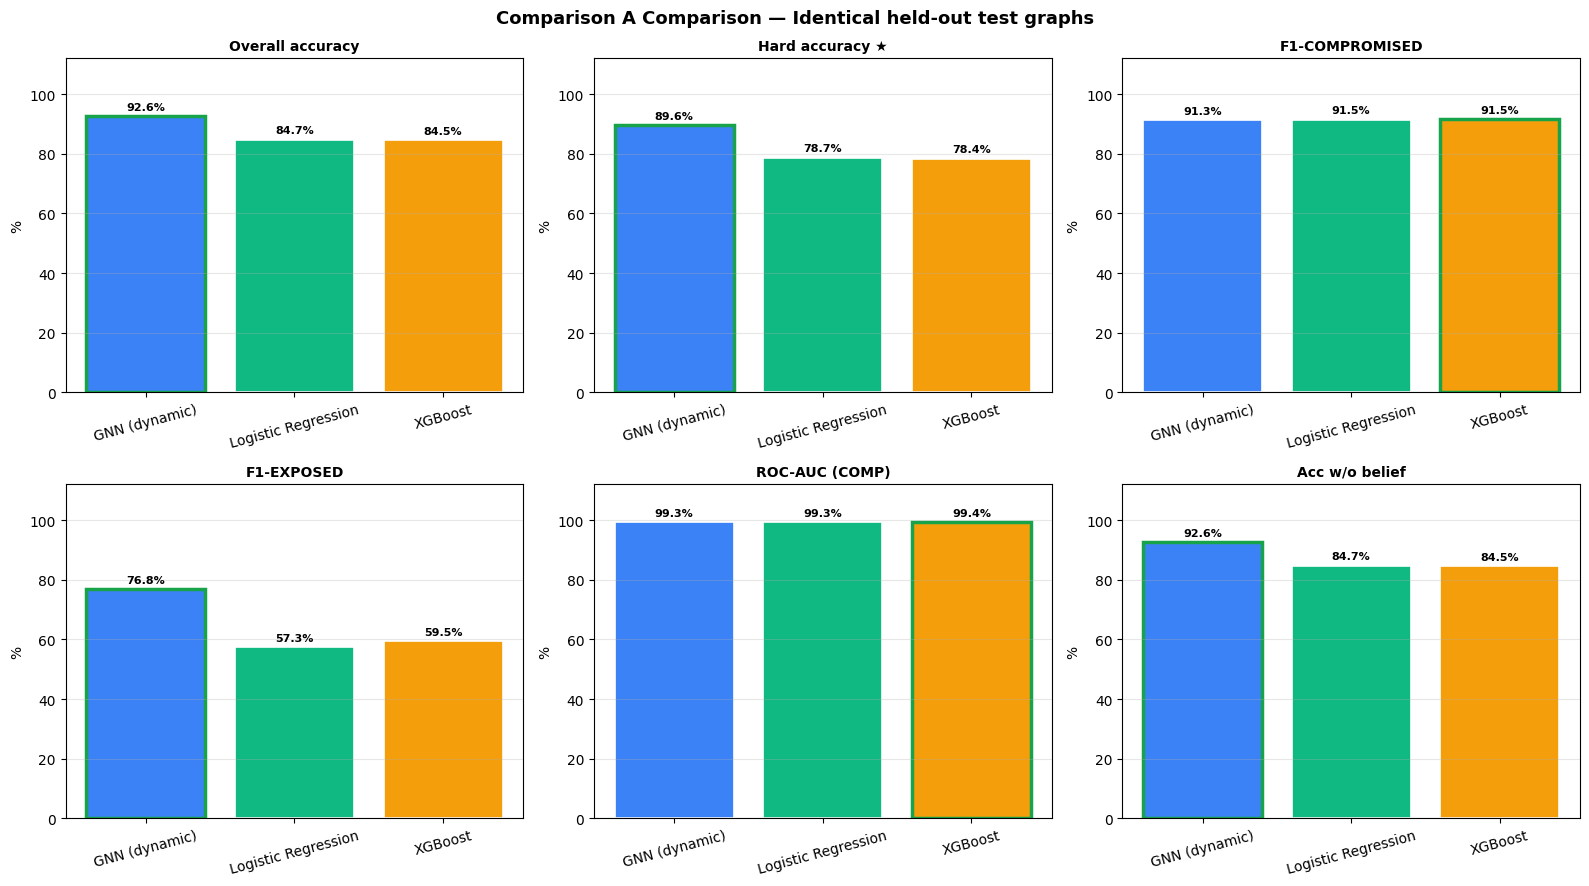

  Plot → data/comparison_comparison_a.png


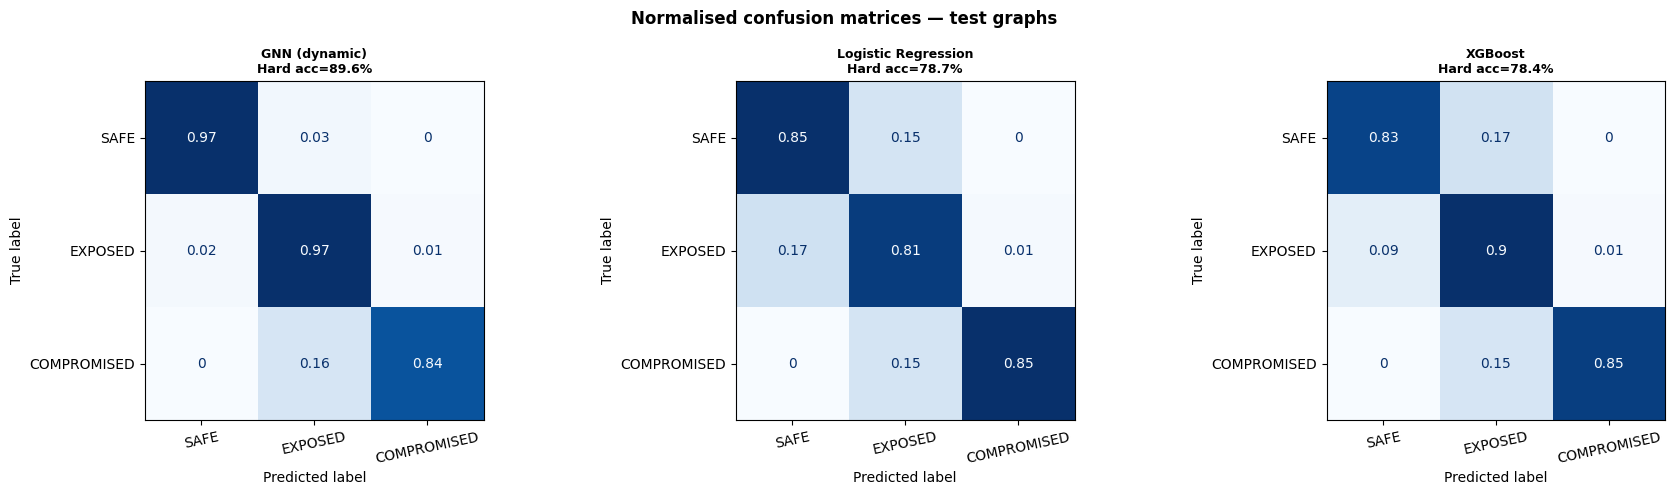

  Confusion matrix → data/confusion_comparison_a.png


████████████████████████████████████████████████████████████
  COMPARISON B: GNN-dynamic vs GNN-static
  (isolates value of discrete-time simulation features)
████████████████████████████████████████████████████████████

GNN — DYNAMIC FEATURES (belief, state, sim trajectory)

 Epoch    TrLoss    TrAcc    VaLoss    VaAcc         LR
-------------------------------------------------------
     1    0.3402   88.08%    0.2207   91.14%   8.71e-03
     2    0.2909   89.49%    0.2445   88.47%   8.71e-03
     3    0.2851   89.63%    0.2271   89.72%   8.71e-03
     4    0.2775   89.76%    0.2067   91.13%   8.71e-03
     5    0.2769   89.68%    0.2025   91.32%   8.71e-03
     6    0.2730   89.72%    0.2179   90.24%   8.71e-03
     7    0.2728   89.73%    0.2060   90.69%   8.71e-03
     8    0.2679   89.92%    0.1906   91.32%   8.71e-03
     9    0.2709   89.63%    0.2200   90.64%   8.71e-03
    10    0.2680   90.03%    0.1942   91.16%   8.71e

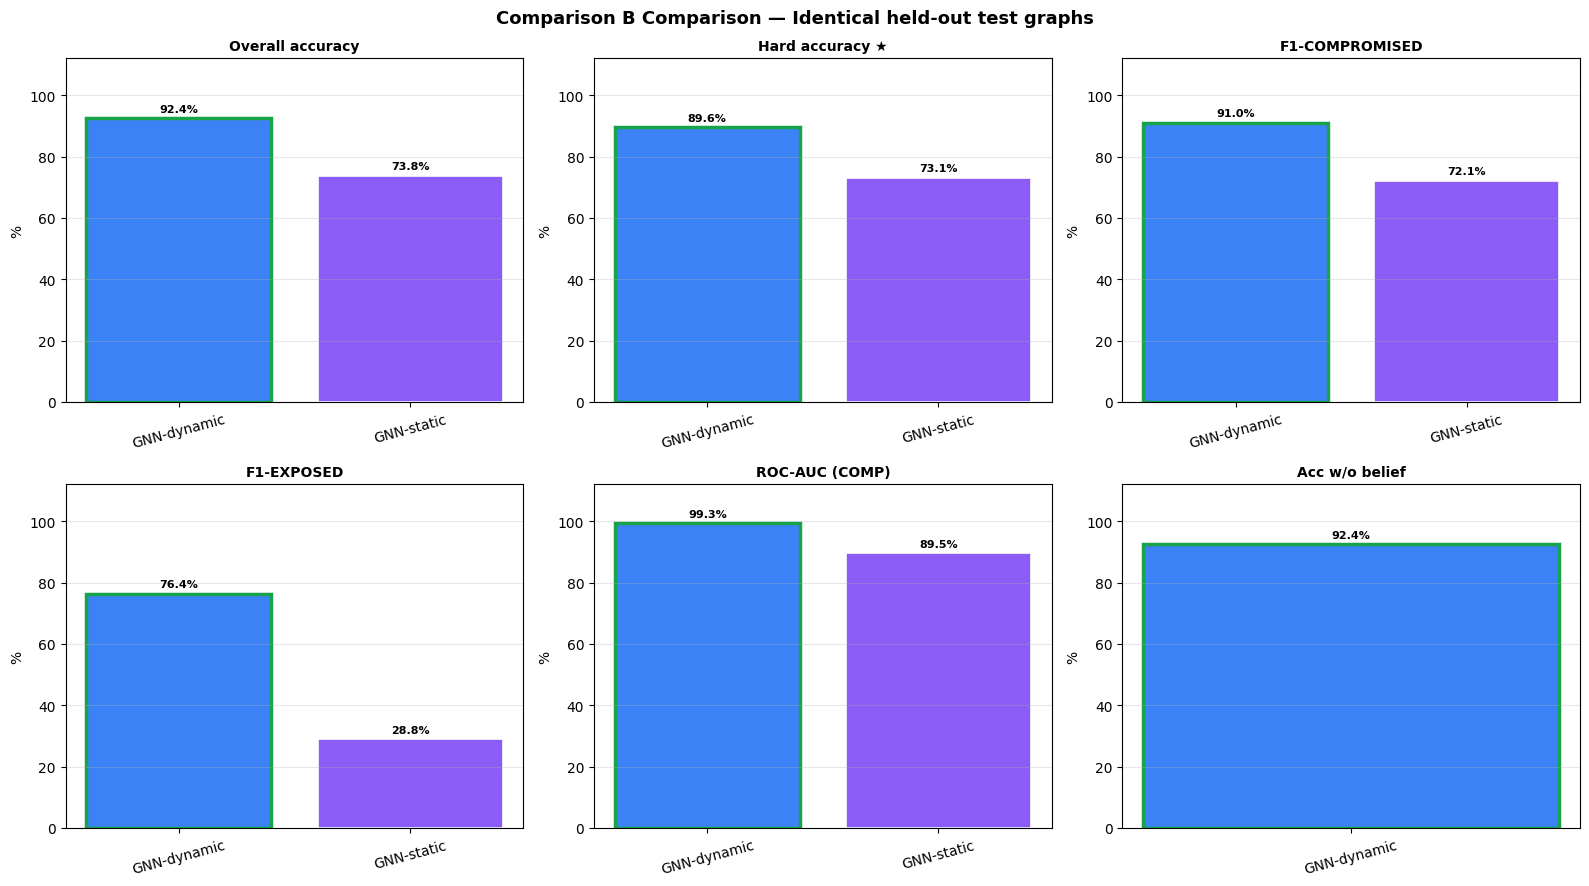

  Plot → data/comparison_comparison_b.png


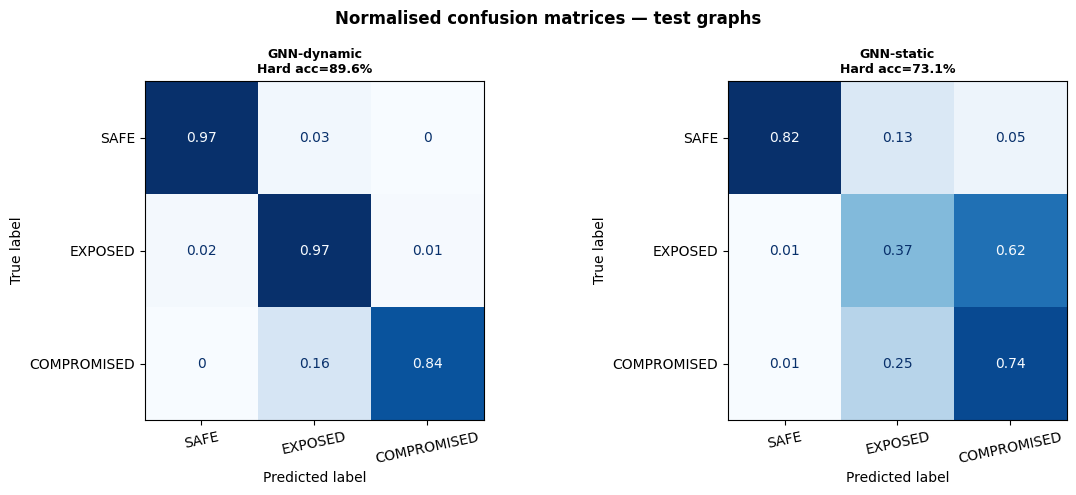

  Confusion matrix → data/confusion_comparison_b.png


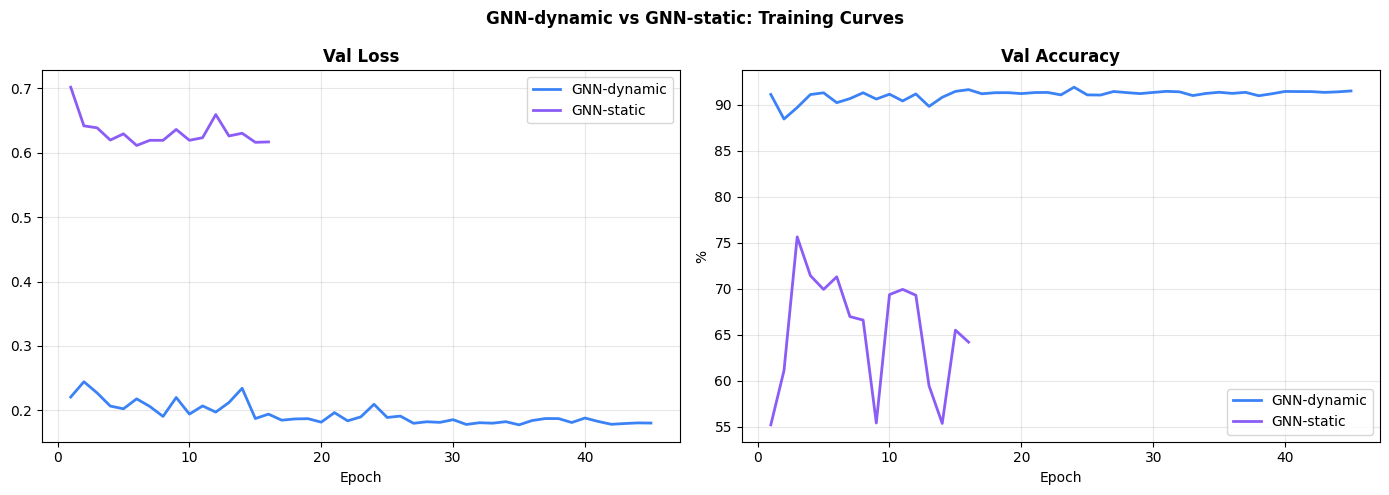

  Plot → data/training_curves_comparison.png


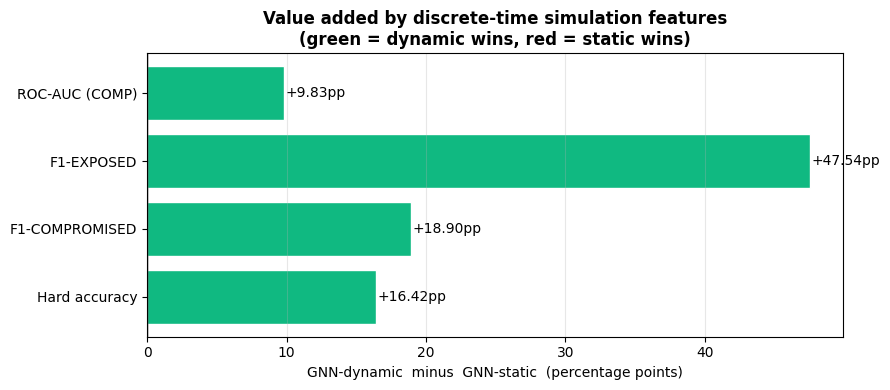

  Gap chart → data/dynamic_vs_static_gap.png

All results saved → data/all_results_v2.json


In [ ]:
!pip install optuna xgboost -q

# Dataset generation (skip if already done and CSV exists)
df = generate_full_dataset(
    num_graphs      = 150,
    sims_per_graph  = 5,
    max_steps       = 20,
    cve_db          = "data/cve.db",
    output_csv      = "data/attack_graph_dataset.csv",
)

# Run full corrected pipeline
results = run_full_pipeline_v2(
    csv_path        = "data/attack_graph_dataset.csv",
    n_train_graphs  = 100,
    n_val_graphs    = 20,
    n_test_graphs   = 30,
    n_optuna_trials = 30,
    epochs          = 100,
    patience        = 10,
    save_dir        = "data",
    random_seed     = 42,
)